# Final Project
## Machine Learning for Neuroscience
### Gaia Negev and Tzlil Tabib

In [118]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import shap
import warnings
import joblib
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import auc as sklearn_auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import adjusted_rand_score, silhouette_score, roc_curve, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Initial Data Handling
Loading, organizing and dividing to train and test

In [ ]:
# # load data from json
# with open('data/emoset_challenge_1000_augmented.json', 'r', encoding='utf-8') as f:
#     data = json.load(f)

# # data to pd.DataFrame
# df = pd.DataFrame(data)
# df_annotations = pd.DataFrame(df['annotations'].tolist())
# df = pd.concat([df.drop('annotations', axis=1), df_annotations], axis=1)
# df.head()

# # remove image_name column because it's duplicated in image_id
# df = df.drop('image_name', axis=1)
# # make image_id the index
# df = df.set_index('image_id')
# df.head()

# # divide data to train and test - stratified by emotion (insure that all emotions are represented in both sets)
# train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])
# print(f'Train size: {len(train_df)}, Test size: {len(test_df)}')

# # save division to csv
# train_df.to_csv('data/train.csv')
# test_df.to_csv('data/test.csv')

In [120]:
# load the data 
train_df = pd.read_csv('data/train.csv', index_col='image_id')
test_df = pd.read_csv('data/test.csv', index_col='image_id')

# EDA

In [121]:
train_df.info()

# null analysis
train_df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 800 entries, amusement_03696 to disgust_02898
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   description                800 non-null    str    
 1   embedding                  800 non-null    str    
 2   viewer_feelings            800 non-null    str    
 3   description_embedding      800 non-null    str    
 4   viewer_feelings_embedding  800 non-null    str    
 5   emotion                    800 non-null    str    
 6   brightness                 799 non-null    float64
 7   colorfulness               781 non-null    float64
 8   facial_expression          94 non-null     str    
 9   object                     412 non-null    str    
 10  human_action               84 non-null     str    
 11  scene                      174 non-null    str    
dtypes: float64(2), str(10)
memory usage: 81.2+ KB


description                    0
embedding                      0
viewer_feelings                0
description_embedding          0
viewer_feelings_embedding      0
emotion                        0
brightness                     1
colorfulness                  19
facial_expression            706
object                       388
human_action                 716
scene                        626
dtype: int64

                           null_count  null_pct
human_action                      716      89.5
facial_expression                 706      88.2
scene                             626      78.2
object                            388      48.5
colorfulness                       19       2.4
brightness                          1       0.1
embedding                           0       0.0
description                         0       0.0
description_embedding               0       0.0
viewer_feelings                     0       0.0
viewer_feelings_embedding           0       0.0
emotion                             0       0.0


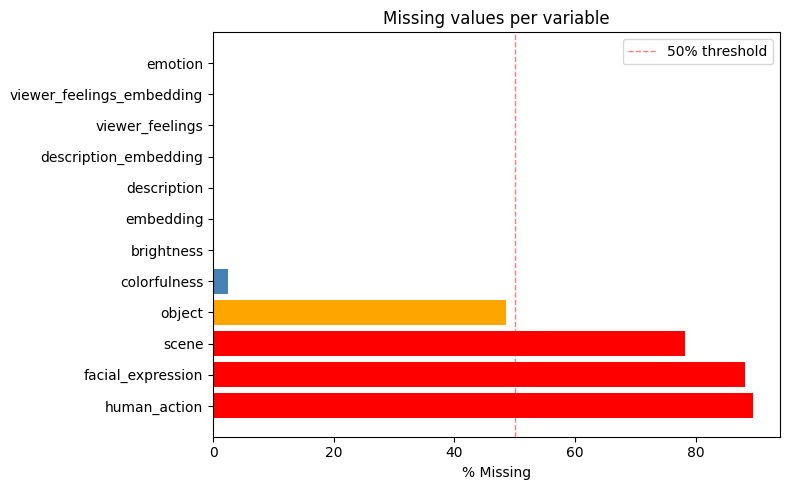

In [122]:
total = len(train_df)
null_counts = train_df.isnull().sum()
null_pct = (null_counts / total * 100).round(1)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct
}).sort_values('null_pct', ascending=False)

print(null_summary.to_string())

# Plot
plt.figure(figsize=(8, 5))
colors = ['red' if p > 50 else 'orange' if p > 10 else 'steelblue' 
          for p in null_summary['null_pct']]
plt.barh(null_summary.index, null_summary['null_pct'], color=colors)
plt.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
plt.xlabel('% Missing')
plt.title('Missing values per variable')
plt.legend()
plt.tight_layout()
plt.show()

Since most of the samples are missing facial_expression, human_action and scence - we'll consider leaving these variables out of the analysis. 

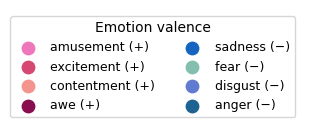

In [123]:
# Emotion valence mapping - color coding in visualizations
# Positive emotions → warm colors
# Negative emotions → cool colors

emotion_colors = {
    'amusement':   "#EE77BC", 
    'excitement':  "#D64772", 
    'contentment': "#F3958E", 
    'awe':         '#880E4F', 
    'sadness':     '#1565C0', 
    'fear':        "#84BEAD",  
    'disgust':     "#617BD1", 
    'anger':       "#1E6391",  
}
# Canonical emotion order (alphabetical, matches LabelEncoder)
encoder_order = sorted(emotion_colors.keys())

def plot_emotion_legend(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 1))
    
    positive = ['amusement', 'excitement', 'contentment', 'awe']
    negative = ['sadness', 'fear', 'disgust', 'anger']
    
    for i, e in enumerate(positive):
        ax.scatter([], [], color=emotion_colors[e], label=f'{e} (+)', s=80)
    for i, e in enumerate(negative):
        ax.scatter([], [], color=emotion_colors[e], label=f'{e} (−)', s=80)
    
    ax.legend(ncol=2, fontsize=9, title='Emotion valence')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_emotion_legend()

emotion
contentment    103
awe            102
amusement      101
sadness        101
anger          100
fear           100
excitement      97
disgust         96
Name: count, dtype: int64


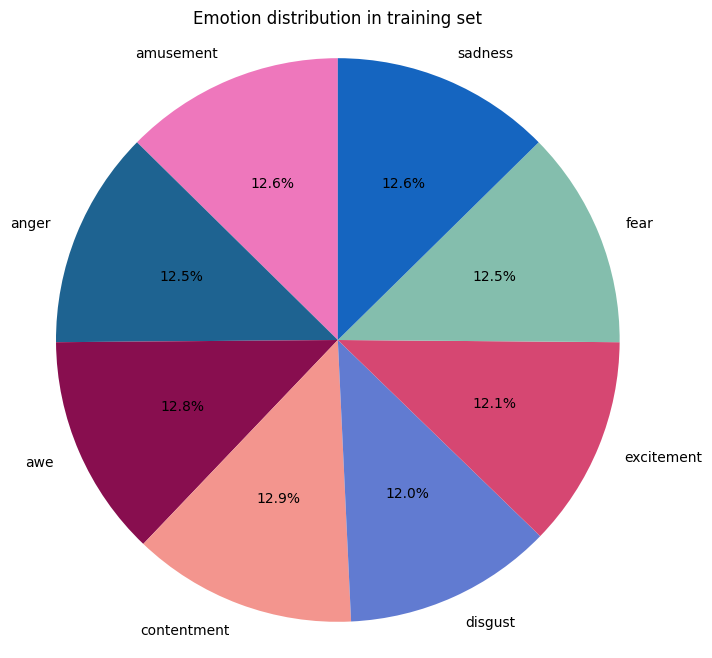

In [124]:
# emotion distribution to see if there is a class imbalance
emotion_counts = train_df['emotion'].value_counts()
print(emotion_counts)

emotion_counts_ordered = train_df['emotion'].value_counts().reindex(encoder_order)
plt.figure(figsize=(8, 8))
plt.pie(
    emotion_counts_ordered,
    labels=emotion_counts_ordered.index,
    colors=[emotion_colors[e] for e in emotion_counts_ordered.index],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Emotion distribution in training set')
plt.axis('equal')
plt.show()

The emotion classes are relatively balanced (each ~12-13%), so we do not apply class weighting in our models. With roughly equal representation, standard loss functions are not biased toward majority classes, and macro-averaged metrics remain meaningful without reweighting.

# Data Preprocessing Plan 
1. Numeric variables: brightness, colorfulness; standarize and fill nulls using median
2. Category variables: emotion; label encoding
3. Text variables: description, viewer_feelings, object; tfidf

## Numerics Variables

In [125]:
# TODO: I wonder if maybe we should use the common to fill missing values because these 
# are not sequential numbers.

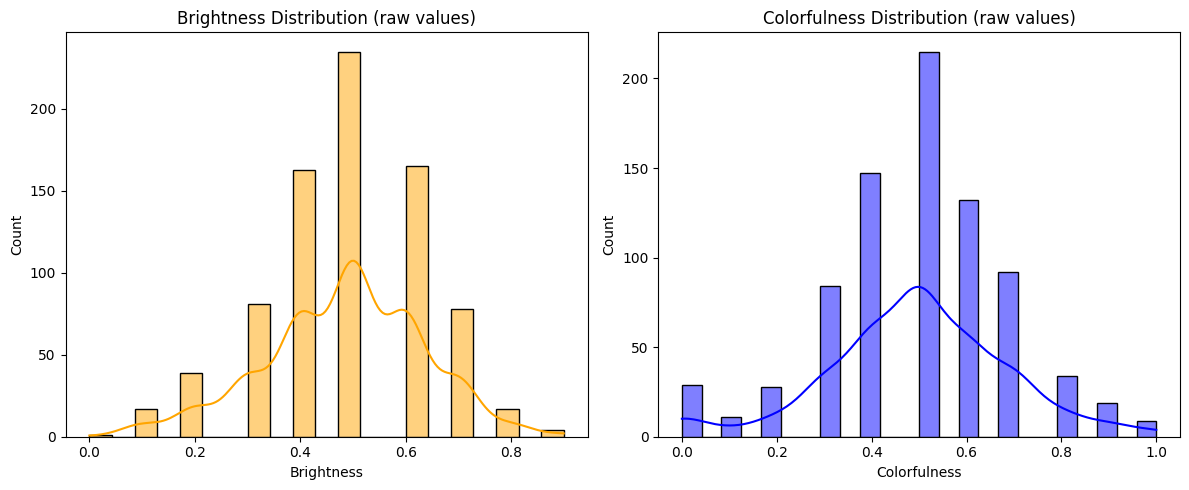

Correlation between brightness and colorfulness: 0.23


In [126]:
train_df.describe()

# Impute the few missing numeric values with median (preprocessing hasn't run yet)
brightness_col = train_df['brightness'].fillna(train_df['brightness'].median())
colorfulness_col = train_df['colorfulness'].fillna(train_df['colorfulness'].median())
X_numeric = np.column_stack([brightness_col, colorfulness_col])

# visualize the distributions of brightness and colorfulness by histogram
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_numeric[:, 0], kde=True, color='orange')
plt.title('Brightness Distribution (raw values)')
plt.xlabel('Brightness')
plt.subplot(1, 2, 2)
sns.histplot(X_numeric[:, 1], kde=True, color='blue')
plt.title('Colorfulness Distribution (raw values)')
plt.xlabel('Colorfulness')
plt.tight_layout()
plt.show()

# Standardize inline
scaler_numeric = StandardScaler()
X_numeric_scaled = scaler_numeric.fit_transform(X_numeric)

print(f"Correlation between brightness and colorfulness: {np.corrcoef(X_numeric_scaled[:, 0], X_numeric_scaled[:, 1])[0, 1]:.2f}")

We see a low correlation between brightness and colorfulness, suggesting each holds unique information.

## Labeling emotion - target variable

In [127]:
# Encode emotion labels
le_eda = LabelEncoder()
target = le_eda.fit_transform(train_df['emotion'])
# Verify label order matches canonical encoder_order
assert list(le_eda.classes_) == encoder_order, "Label order mismatch!"


## Text Variables - TFIDF
We treat `max_features` of the TF-IDF as a hyperparameter. To select it, we evaluate CV AUC across a coarse grid (steps of 30) and identify the **elbow point** — the last value where adding more features yields a marginal AUC gain above 0.005 per step. A finer grid (steps of 10) is overlaid to confirm no meaningful gains were missed between coarse steps. This approach favors parsimony: beyond the elbow, the curve flattens and additional features increase model complexity with negligible performance benefit, raising the risk of overfitting on a relatively small dataset (N≈800).

In [128]:
def prefix_text(text, prefix):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    words = [w for w in text.lower().split() if w not in ENGLISH_STOP_WORDS]
    return ' '.join(f"{prefix}_{w}" for w in words)

def prefix_object_list(text, prefix):
    """Handle object column which contains list strings like ['Tree', 'Plant']"""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    try:
        items = ast.literal_eval(text)  # parse ['Tree', 'Plant'] -> ['Tree', 'Plant']
        if isinstance(items, list):
            words = [item.lower().strip() for item in items if item.strip()]
            return ' '.join(f"{prefix}_{w}" for w in words)
    except:
        pass
    # fallback: treat as plain text
    return prefix_text(text, prefix)

train_df['combined_text'] = (
    train_df['description'].apply(lambda x: prefix_text(x, 'desc')) + ' ' +
    train_df['viewer_feelings'].apply(lambda x: prefix_text(x, 'feel')) + ' ' +
    train_df['object'].apply(lambda x: prefix_object_list(x, 'obj'))
)

max_features=  50 — AUC mean=0.885  std=0.010
max_features=  80 — AUC mean=0.912  std=0.009
max_features= 110 — AUC mean=0.918  std=0.007
max_features= 140 — AUC mean=0.923  std=0.009
max_features= 170 — AUC mean=0.926  std=0.008
max_features= 200 — AUC mean=0.932  std=0.008
max_features= 230 — AUC mean=0.934  std=0.008

Selected max_features (coarse elbow): 110


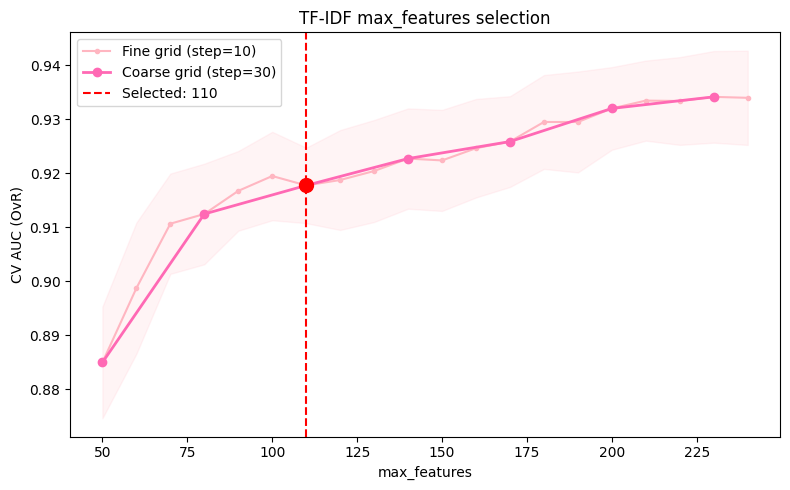


Final TF-IDF shape: (800, 110)


In [129]:
# ── Tune max_features via CV ─────────────────────────────────────────────────
# ── Coarse grid for selection ────────────────────────────────────────────────
max_features_coarse = list(range(50, 250, 30))
cv_tfidf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tfidf_cv_coarse = {}

for mf in max_features_coarse:
    tfidf_temp = TfidfVectorizer(max_features=mf)
    X_temp = tfidf_temp.fit_transform(train_df['combined_text'])
    X_temp_full = hstack([X_temp, csr_matrix(X_numeric_scaled)])
    scores = cross_val_score(
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        X_temp_full, target, cv=cv_tfidf, scoring='roc_auc_ovr'
    )
    tfidf_cv_coarse[mf] = scores
    print(f"max_features={mf:4d} — AUC mean={scores.mean():.3f}  std={scores.std():.3f}")

# ── Fine grid for validation ─────────────────────────────────────────────────
max_features_fine = list(range(50, 250, 10))
tfidf_cv_fine = {}

for mf in max_features_fine:
    tfidf_temp = TfidfVectorizer(max_features=mf)
    X_temp = tfidf_temp.fit_transform(train_df['combined_text'])
    X_temp_full = hstack([X_temp, csr_matrix(X_numeric_scaled)])
    scores = cross_val_score(
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        X_temp_full, target, cv=cv_tfidf, scoring='roc_auc_ovr'
    )
    tfidf_cv_fine[mf] = scores

# ── Elbow selection on coarse grid ───────────────────────────────────────────
means_c = np.array([tfidf_cv_coarse[mf].mean() for mf in max_features_coarse])
marginal_c = np.diff(means_c)
gain_threshold = 0.005

best_max_features = max_features_coarse[0]
for j in range(len(marginal_c)):
    if marginal_c[j] >= gain_threshold:
        best_max_features = max_features_coarse[j + 1]
    else:
        break

print(f"\nSelected max_features (coarse elbow): {best_max_features}")

# ── Plot: coarse selection + fine validation ─────────────────────────────────
means_f = np.array([tfidf_cv_fine[mf].mean() for mf in max_features_fine])
stds_f  = np.array([tfidf_cv_fine[mf].std() for mf in max_features_fine])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(max_features_fine, means_f, marker='.', color='lightpink', linewidth=1.5, label='Fine grid (step=10)')
ax.fill_between(max_features_fine, means_f - stds_f, means_f + stds_f, alpha=0.15, color='lightpink')
ax.plot(max_features_coarse, means_c, marker='o', color='hotpink', linewidth=2, label='Coarse grid (step=30)')
ax.axvline(best_max_features, color='red', linestyle='--', linewidth=1.5, label=f'Selected: {best_max_features}')
ax.scatter([best_max_features], [means_c[max_features_coarse.index(best_max_features)]],
           color='red', s=100, zorder=5)
ax.set_xlabel('max_features')
ax.set_ylabel('CV AUC (OvR)')
ax.set_title('TF-IDF max_features selection')
ax.legend()

plt.tight_layout()
plt.show()

# ── Fit final TF-IDF ────────────────────────────────────────────────────────
tfidf_combined = TfidfVectorizer(max_features=best_max_features)
combined_matrix = tfidf_combined.fit_transform(train_df['combined_text'])
print(f"\nFinal TF-IDF shape: {combined_matrix.shape}")

In [130]:
# present the first 5 rows of combined_matrix
combined_df = pd.DataFrame(combined_matrix[:5].toarray(), columns=tfidf_combined.get_feature_names_out())
print(combined_df.head())
print(combined_df.columns)

      desc_  desc_backdrop  desc_background  desc_black  desc_blue  \
0  0.000000            0.0              0.0         0.0   0.225869   
1  0.000000            0.0              0.0         0.0   0.000000   
2  0.000000            0.0              0.0         0.0   0.000000   
3  0.530074            0.0              0.0         0.0   0.000000   
4  0.000000            0.0              0.0         0.0   0.000000   

   desc_blurred  desc_clear  desc_colorful  desc_dark  desc_features  ...  \
0           0.0         0.0            0.0        0.0            0.0  ...   
1           0.0         0.0            0.0        0.0            0.0  ...   
2           0.0         0.0            0.0        0.0            0.0  ...   
3           0.0         0.0            0.0        0.0            0.0  ...   
4           0.0         0.0            0.0        0.0            0.0  ...   

   feel_unease  feel_vibrant  feel_viewer  feel_warmth  feel_watching  \
0          0.0      0.194335     0.078821  

## Clustering & Dimensionality Reduction
We examine whether the emotion categories form natural clusters in the embedding space before any supervised learning. We apply K-Means (k=8, matching the number of emotions) and compare cluster assignments to true labels using the Adjusted Rand Index. We also visualize the embedding space using PCA and t-SNE.

Adjusted Rand Index (clusters vs. true emotions): 0.310
Silhouette Score: 0.098

Contingency table (rows=true emotions, cols=clusters):
Cluster        0   1   2   3   4   5   6   7
True emotion                                
amusement     55   0   0   0  25  12   9   0
anger          1  15  25  34   0  24   0   1
awe            2   0   7   2   8   6  76   1
contentment    5   1  12   0  45   0  40   0
disgust        5  17  23   3   0   0   2  46
excitement     3   0   1   0  25  65   3   0
fear           5  72  11   6   0   0   1   5
sadness        3   8   5  57   7   1   7  13


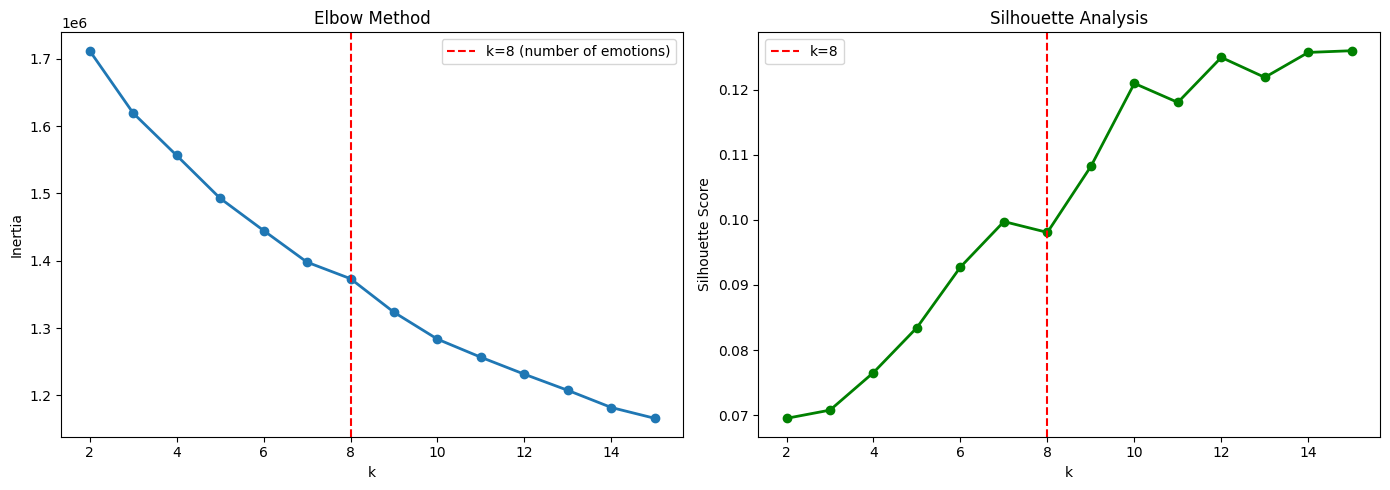

In [131]:
# Parse embeddings for EDA (needed before modeling section)
train_df['embedding_parsed'] = train_df['embedding'].apply(ast.literal_eval)
train_df['desc_emb_parsed'] = train_df['description_embedding'].apply(ast.literal_eval)
train_df['feel_emb_parsed'] = train_df['viewer_feelings_embedding'].apply(ast.literal_eval)

E_image_eda = np.stack(train_df['embedding_parsed'].values)
E_desc_eda  = np.stack(train_df['desc_emb_parsed'].values)
E_feel_eda  = np.stack(train_df['feel_emb_parsed'].values)

# Standardize for EDA
scaler_eda_img  = StandardScaler()
scaler_eda_desc = StandardScaler()
scaler_eda_feel = StandardScaler()
E_img_s  = scaler_eda_img.fit_transform(E_image_eda)
E_desc_s = scaler_eda_desc.fit_transform(E_desc_eda)
E_feel_s = scaler_eda_feel.fit_transform(E_feel_eda)

# Quick PCA to manageable dimensions for clustering
pca_eda_img  = PCA(n_components=50, random_state=42).fit_transform(E_img_s)
pca_eda_desc = PCA(n_components=50, random_state=42).fit_transform(E_desc_s)
pca_eda_feel = PCA(n_components=50, random_state=42).fit_transform(E_feel_s)
X_eda_combined = np.hstack([pca_eda_img, pca_eda_desc, pca_eda_feel])

# ── 1. K-Means clustering (k=8) ─────────────────────────────────────────────
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_eda_combined)

ari = adjusted_rand_score(target, cluster_labels)
sil = silhouette_score(X_eda_combined, cluster_labels, sample_size=min(800, len(target)))
print(f"Adjusted Rand Index (clusters vs. true emotions): {ari:.3f}")
print(f"Silhouette Score: {sil:.3f}")

# ── 2. Contingency table: clusters vs true emotions ─────────────────────────
contingency = pd.crosstab(
    pd.Series(target, name='True emotion').map(dict(enumerate(encoder_order))),
    pd.Series(cluster_labels, name='Cluster')
)
print("\nContingency table (rows=true emotions, cols=clusters):")
print(contingency)

# ── 3. Elbow plot: try different k values ────────────────────────────────────
k_range = range(2, 16)
inertias = []
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_eda_combined)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_eda_combined, km.labels_, sample_size=min(800, len(target))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker='o', linewidth=2)
axes[0].axvline(8, color='red', linestyle='--', label='k=8 (number of emotions)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].legend()

axes[1].plot(k_range, sil_scores, marker='o', linewidth=2, color='green')
axes[1].axvline(8, color='red', linestyle='--', label='k=8')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].legend()
plt.tight_layout()
plt.show()

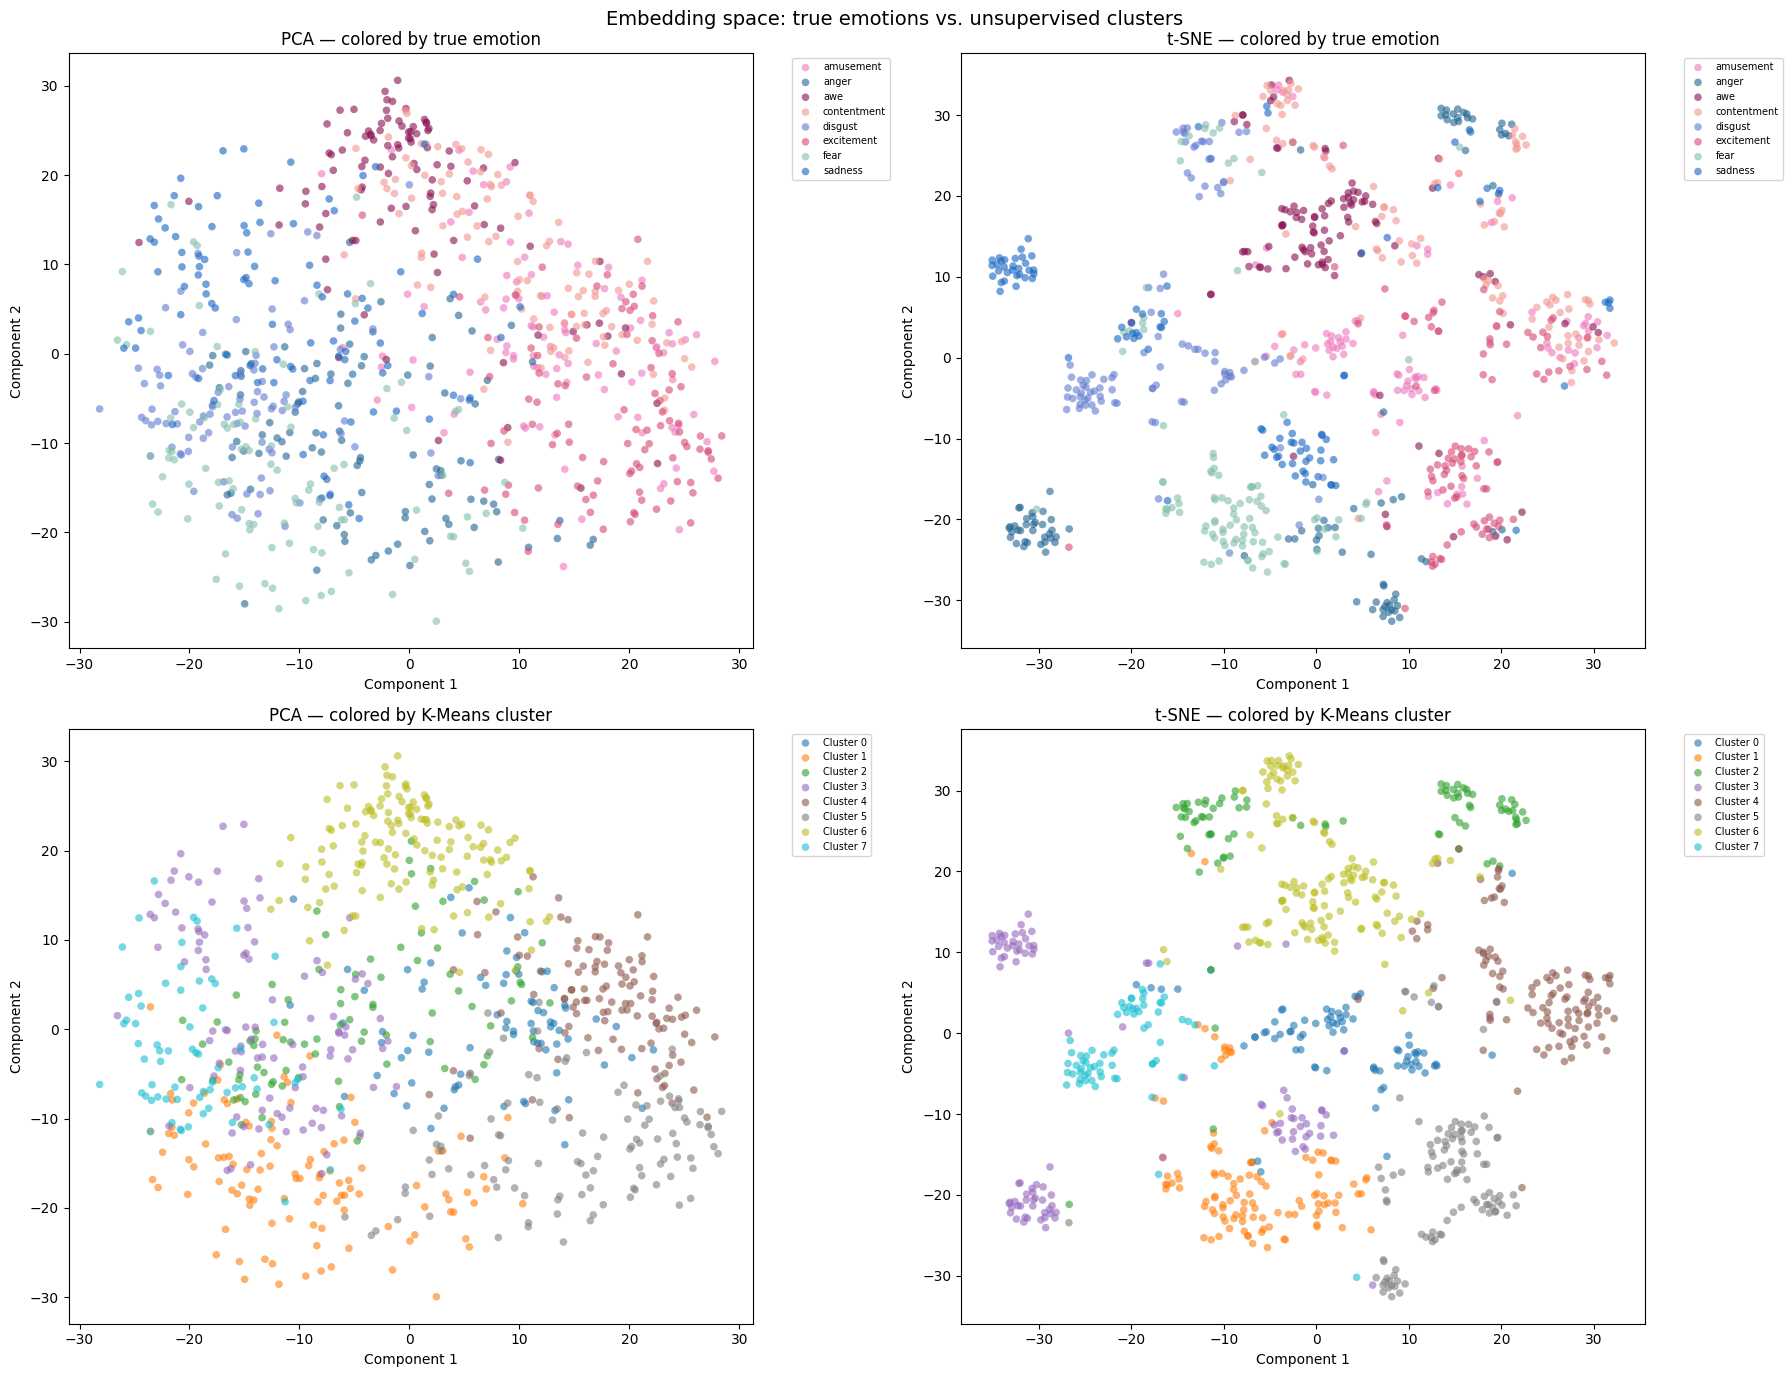

In [132]:
# # ── Dimensionality reduction visualization ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d_pca = pca_2d.fit_transform(X_eda_combined)

# t-SNE 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_2d_tsne = tsne.fit_transform(X_eda_combined)

# Top row: colored by true emotion
for ax, X_2d, title in zip(axes[0], [X_2d_pca, X_2d_tsne], ['PCA', 't-SNE']):
    for idx, emotion in enumerate(encoder_order):
        mask = target == idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=emotion,
                   color=emotion_colors[emotion],
                   alpha=0.6, s=30, edgecolors='none')
    ax.set_title(f'{title} — colored by true emotion', fontsize=12)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

# Bottom row: colored by K-Means cluster
cluster_cmap = plt.cm.get_cmap('tab10', 8)
for ax, X_2d, title in zip(axes[1], [X_2d_pca, X_2d_tsne], ['PCA', 't-SNE']):
    for c in range(8):
        mask = cluster_labels == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=f'Cluster {c}',
                   color=cluster_cmap(c),
                   alpha=0.6, s=30, edgecolors='none')
    ax.set_title(f'{title} — colored by K-Means cluster', fontsize=12)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Embedding space: true emotions vs. unsupervised clusters', fontsize=14)
plt.tight_layout()
plt.show()

The Adjusted Rand Index indicates the degree of agreement between unsupervised K-Means clusters and the true emotion labels. A moderate ARI suggests that while the embedding space captures some of the emotion structure, the eight discrete emotion categories do not map cleanly onto separable clusters — consistent with the dimensional view of affect where emotions blend along valence and arousal axes rather than forming discrete islands. The t-SNE plot shows some separation (particularly between positive and negative valence), but considerable overlap between within-valence emotions like fear/anger or amusement/excitement.

# Modeling 

## 1. Tabular model
Steps: 
1. Choose few potential models
2. Use cross validation on the training set - use GridSearchCV to do hyperparameter tunning
3. Assess feature importance
4. Evaluate performance of best model on the test set and interpret

In [133]:
# Variables to include:
# - brightness
# - colorfulness
# - features from the text columns (after TF-IDF - description, viewer_feelings, object)

In [134]:
warnings.filterwarnings('ignore')

# ── 1. Assemble feature matrix ────────────────────────────────────────────────
X_train = hstack([combined_matrix, csr_matrix(X_numeric_scaled)])
y_train = target
print(f"Feature matrix shape: {X_train.shape}")

# ── 2. Define models with hyperparameter grids ────────────────────────────────
coarse_grids = {
    'Logistic Regression (L1)': (
        LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Logistic Regression (L2)': (
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 10]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5]}
    ),
}

# ── 3. Coarse tuning + CV evaluation ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
models = {}  # store best estimators for later use (ROC curves etc.)

for name, (model, grid) in coarse_grids.items():
    gs = GridSearchCV(model, grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1)
    gs.fit(X_train, y_train)
    best = gs.best_estimator_

    # Compute all metrics on best estimator
    acc       = cross_val_score(best, X_train, y_train, cv=cv, scoring='accuracy')
    precision = cross_val_score(best, X_train, y_train, cv=cv, scoring='precision_macro')
    recall    = cross_val_score(best, X_train, y_train, cv=cv, scoring='recall_macro')
    auc       = cross_val_score(best, X_train, y_train, cv=cv, scoring='roc_auc_ovr')

    results[name] = {
        'accuracy':    acc,
        'precision':   precision,
        'recall':      recall,
        'auc':         auc,
        'best_params': gs.best_params_,
    }
    models[name] = best  # save for ROC curves

    print(f"\n{name}  best_params={gs.best_params_}")
    for metric, scores in results[name].items():
        if metric == 'best_params':
            continue
        print(f"  {metric:22s} mean={scores.mean():.3f}  std={scores.std():.3f}")

# ── 4. Select best model by AUC ───────────────────────────────────────────────
best_model_name = max(
    {k: v for k, v in results.items()},
    key=lambda x: results[x]['auc'].mean()
)
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name}  AUC={results[best_model_name]['auc'].mean():.3f}")

Feature matrix shape: (800, 112)

Logistic Regression (L1)  best_params={'C': 1}
  accuracy               mean=0.573  std=0.042
  precision              mean=0.581  std=0.050
  recall                 mean=0.574  std=0.041
  auc                    mean=0.906  std=0.010

Logistic Regression (L2)  best_params={'C': 1}
  accuracy               mean=0.605  std=0.017
  precision              mean=0.613  std=0.021
  recall                 mean=0.606  std=0.016
  auc                    mean=0.918  std=0.007

Random Forest  best_params={'max_depth': None, 'n_estimators': 200}
  accuracy               mean=0.585  std=0.023
  precision              mean=0.593  std=0.022
  recall                 mean=0.586  std=0.023
  auc                    mean=0.914  std=0.011

Gradient Boosting  best_params={'max_depth': 3, 'n_estimators': 100}
  accuracy               mean=0.547  std=0.018
  precision              mean=0.552  std=0.023
  recall                 mean=0.549  std=0.017
  auc                    me

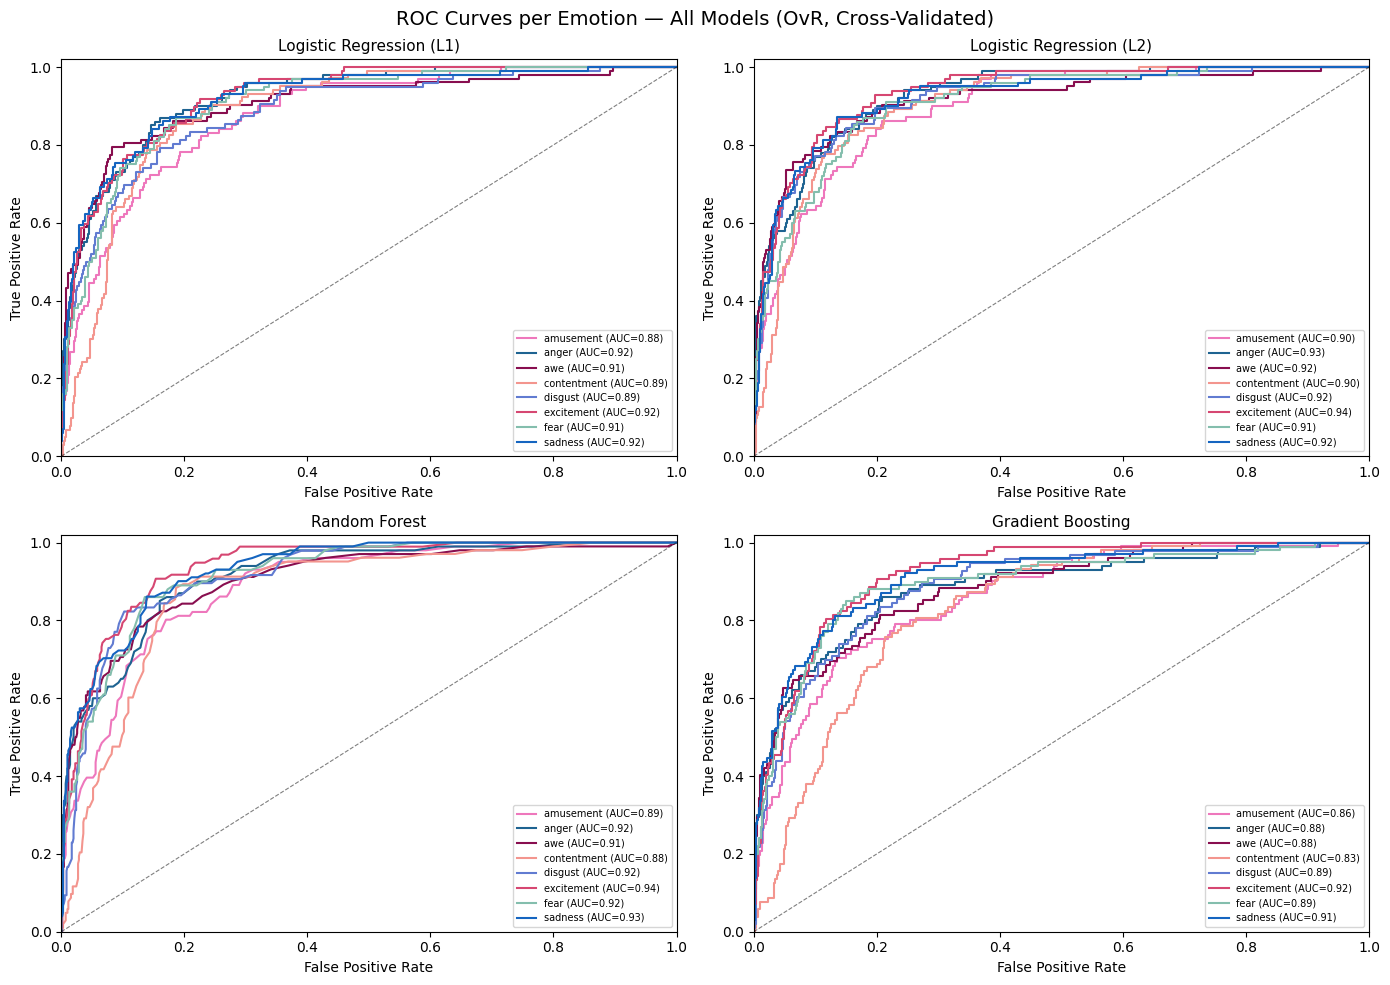

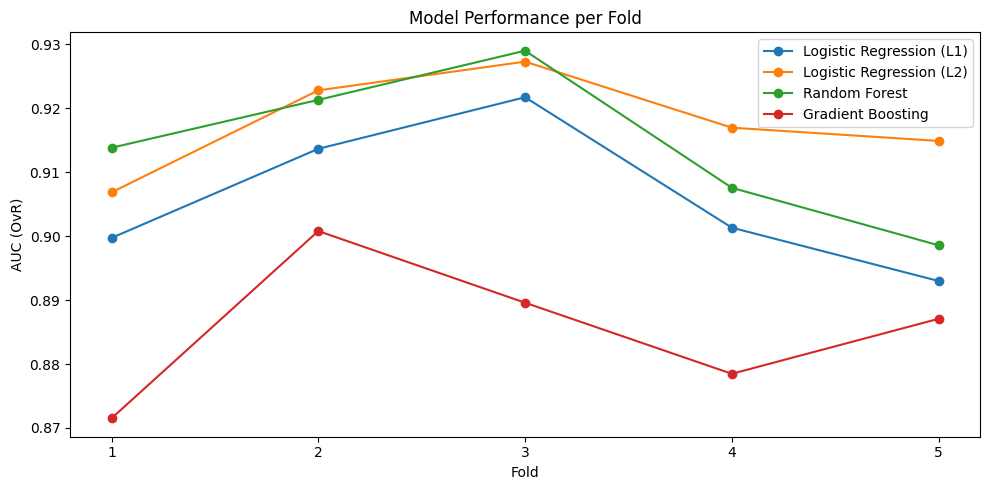

In [135]:
# ── 1. ROC curves (models dict now contains tuned estimators) ─────────────────
y_bin = label_binarize(y_train, classes=range(len(encoder_order)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 4 models → 2x2 grid
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_prob = cross_val_predict(
        model, X_train, y_train, cv=cv, method='predict_proba'
    )
    for i, emotion in enumerate(encoder_order):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=emotion_colors[emotion], linewidth=1.5,
                label=f"{emotion} (AUC={roc_auc:.2f})")
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves per Emotion — All Models (OvR, Cross-Validated)', fontsize=14)
plt.tight_layout()
plt.show()

# ── 3. Score per fold plot ────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
for name, metrics in results.items():
    plt.plot(range(1, 6), metrics['auc'], marker='o', label=name)  # plot AUC per fold
plt.xlabel('Fold')
plt.xticks(range(1, 6))
plt.ylabel('AUC (OvR)')
plt.title('Model Performance per Fold')
plt.legend()
plt.tight_layout()
plt.show()

Logistic Regression (L2) achieved the highest AUC and is also the most interpretable model for feature analysis (direct coefficient inspection + linear SHAP). We therefore proceed with LR for the feature importance and selection stages. The tree-based models showed lower performance on this feature set, likely because the TF-IDF features are high-dimensional and sparse, which suits regularized linear models better than tree-based splitting.

The AUC is substantially higher than accuracy across all models. This is expected in an 8-class problem: AUC (One-vs-Rest, macro) measures each class's ranking ability independently, while accuracy requires the model to commit to a single label. With random-chance accuracy at 12.5% (1/8), even our modest accuracy scores represent meaningful discrimination. The gap between AUC and accuracy suggests the models can distinguish emotional valence and arousal dimensions but struggle with fine-grained categorical boundaries — for example, correctly ranking 'fear' higher than 'amusement' for a fearful image while sometimes mislabeling it as 'disgust' (a neighboring negative emotion)

### Feature importance analysis on the best model

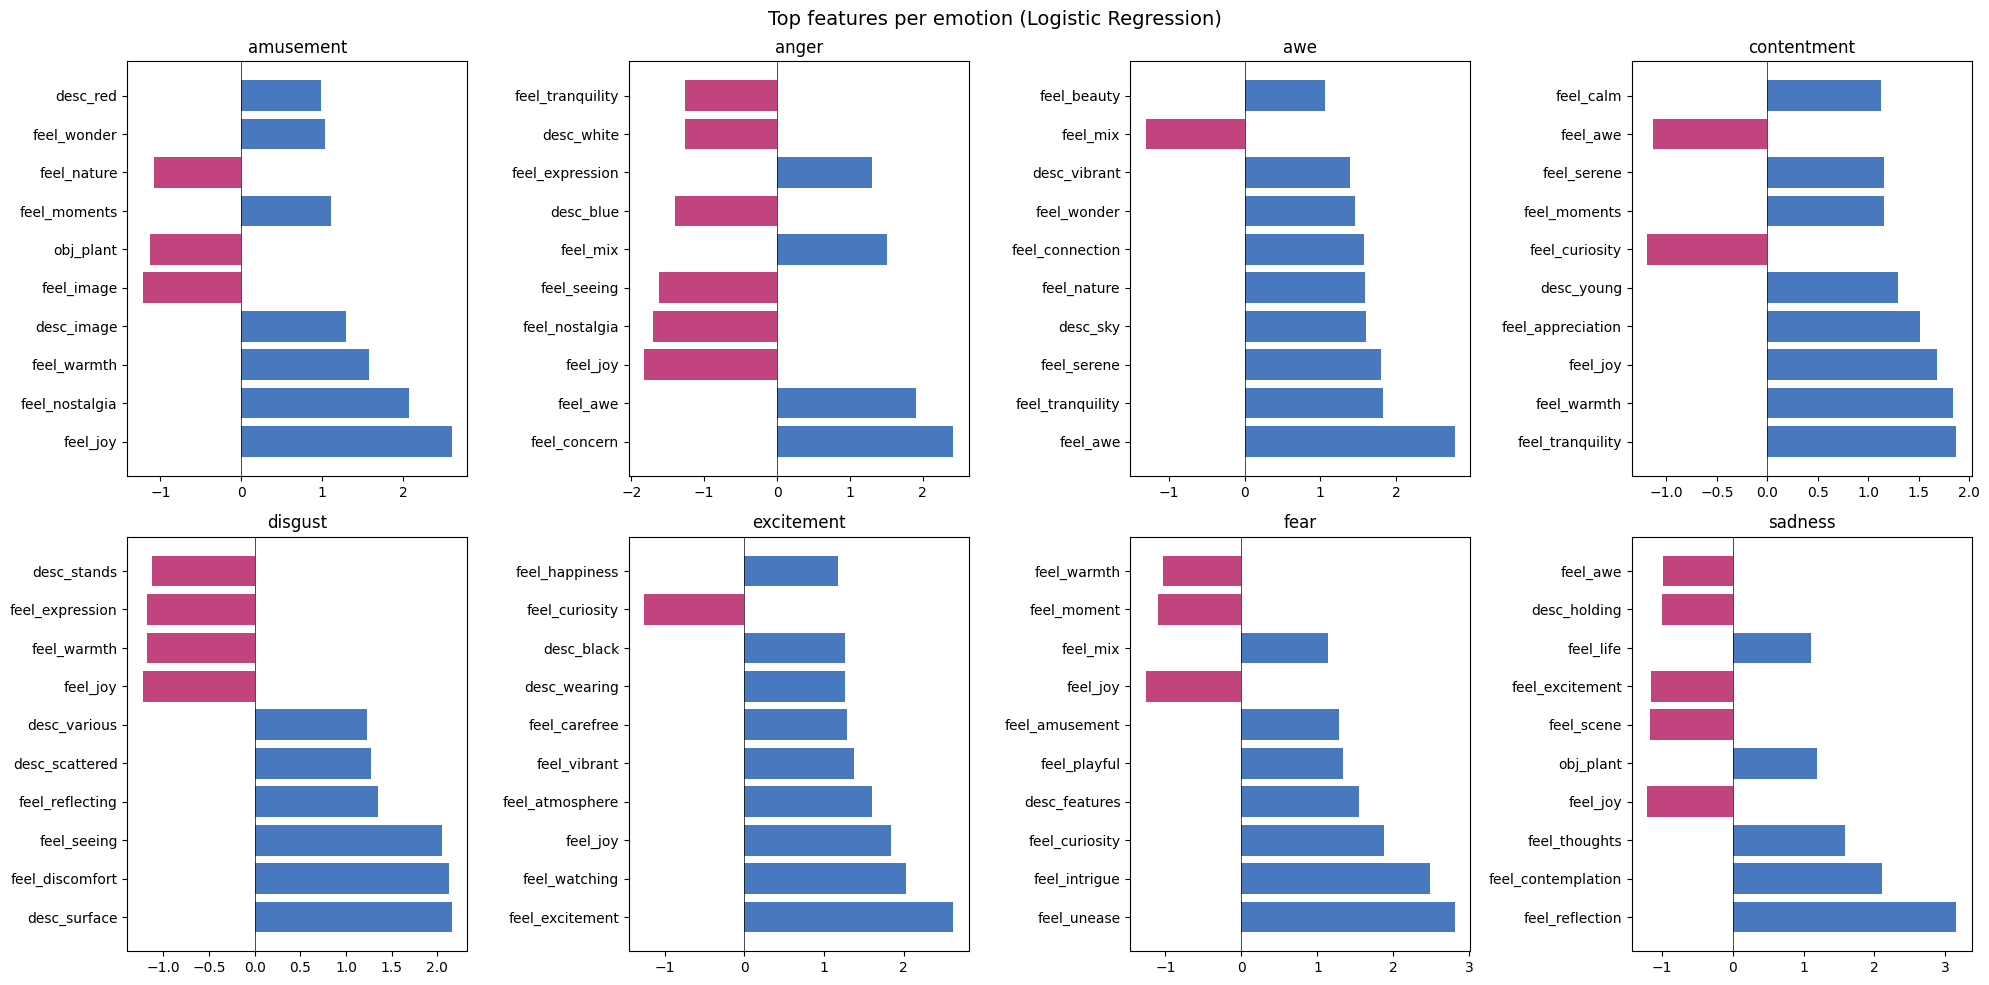

In [136]:
# Get feature names (TF-IDF + numeric)
feature_names = list(tfidf_combined.get_feature_names_out()) + ['brightness', 'colorfulness']

# ── For Logistic Regression ──────────────────────────────────────────────────
# coef_ shape is (n_classes, n_features) - one row per emotion
coef_df = pd.DataFrame(
    best_model.coef_,
    index=encoder_order,
    columns=feature_names
)

# Plot top N features per emotion
n_top = 10
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, emotion in enumerate(encoder_order):
    top_features = coef_df.loc[emotion].abs().nlargest(n_top)
    colors = ['#C2447F' if coef_df.loc[emotion, f] < 0 else "#4878BE" for f in top_features.index]
    axes[i].barh(top_features.index, coef_df.loc[emotion, top_features.index], color=colors)
    axes[i].set_title(emotion)
    axes[i].axvline(0, color='black', linewidth=0.5)

plt.suptitle('Top features per emotion (Logistic Regression)', fontsize=14)
plt.tight_layout()
plt.show()

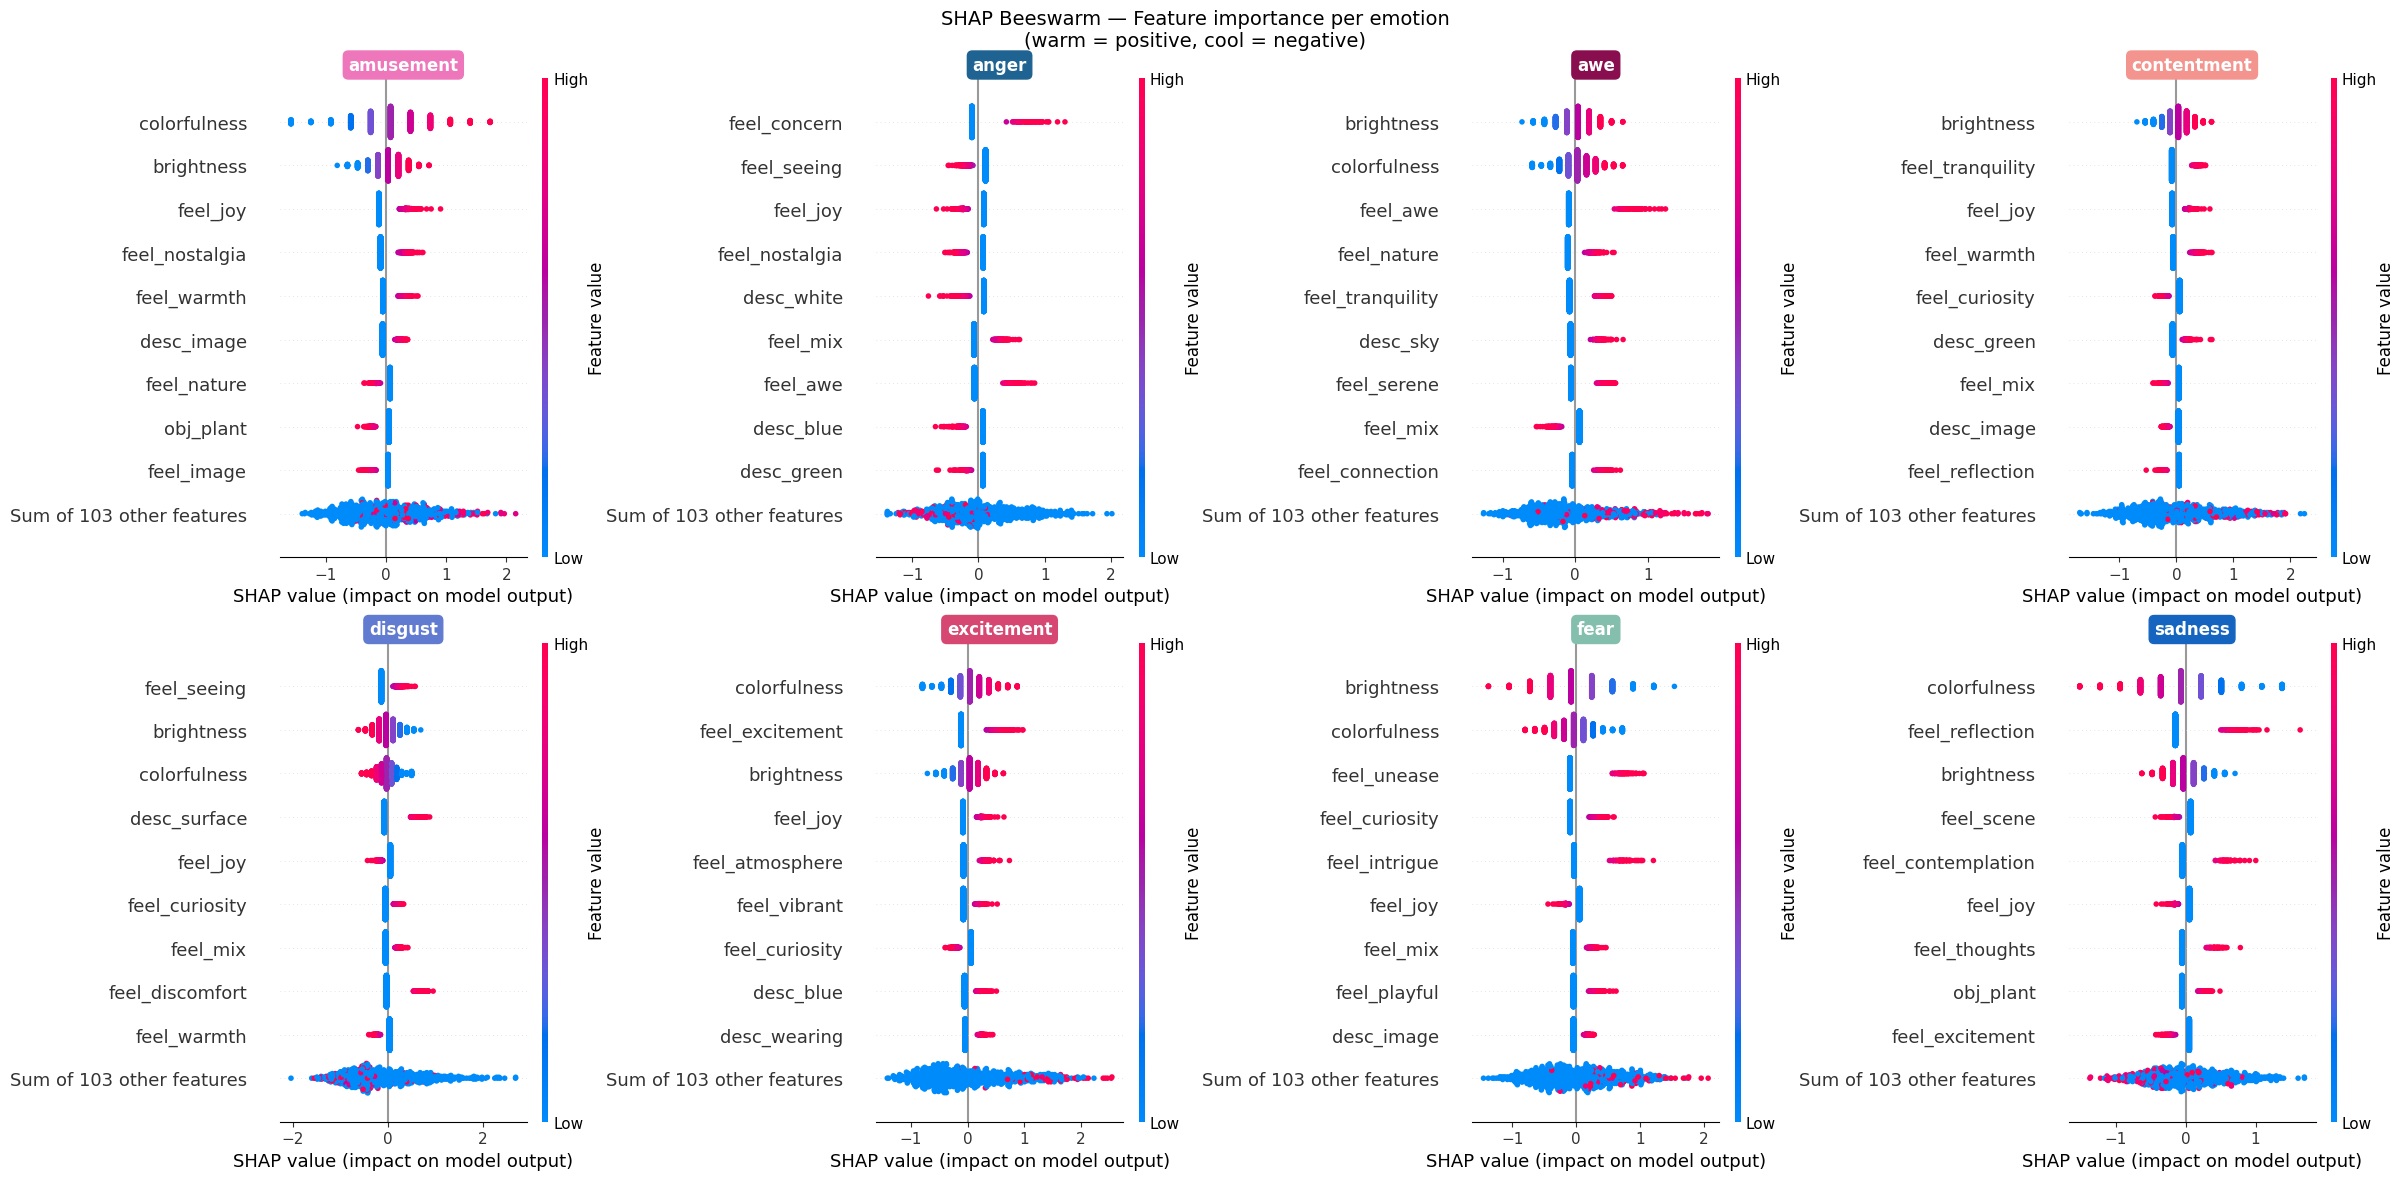

In [137]:
X_train_dense = pd.DataFrame(
    X_train.toarray(),
    columns=feature_names
)

explainer = shap.LinearExplainer(best_model, X_train_dense)
shap_values = explainer(X_train_dense)

# ── Plot all emotions in one figure ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, emotion in enumerate(encoder_order):
    plt.sca(axes[i])  # set current axis for shap to draw on
    
    shap.plots.beeswarm(
        shap_values[:, :, i],
        max_display=10,
        show=False,        # don't render yet
        plot_size=None     # use our axis size
    )
    
    # Add emotion color as a title badge
    color = emotion_colors[emotion]
    axes[i].set_title(emotion, fontsize=12, fontweight='bold',
                      color='white',
                      bbox=dict(facecolor=color, edgecolor=color, 
                                boxstyle='round,pad=0.3'))

plt.suptitle('SHAP Beeswarm — Feature importance per emotion\n(warm = positive, cool = negative)',
             fontsize=14)
plt.tight_layout()
plt.show()

### Feature Selection via SHAP
Having interpreted the model's per-emotion feature importance above, we now use the aggregate SHAP importance to select an optimal feature subset

Note: SHAP-based feature ranking was computed on the full training set before CV. This introduces a mild optimistic bias in the CV AUC estimates for the feature-cutoff search, since the ranking was informed by all samples including those held out in each fold. In practice, the ranking is expected to be stable across folds given the sample size

             feature  mean_abs_shap
0       colorfulness       0.228663
1         brightness       0.183592
2           feel_joy       0.113067
3           feel_mix       0.067183
4     feel_curiosity       0.067110
5    feel_excitement       0.067034
6     feel_nostalgia       0.066427
7    feel_reflection       0.065885
8        feel_nature       0.064780
9         desc_image       0.063813
10          feel_awe       0.063671
11      feel_concern       0.063134
12       feel_seeing       0.062446
13  feel_tranquility       0.062252
14       feel_warmth       0.053863
15        feel_scene       0.048902
16       feel_unease       0.047871
17       feel_moment       0.044052
18       feel_serene       0.042677
19          desc_sky       0.041683


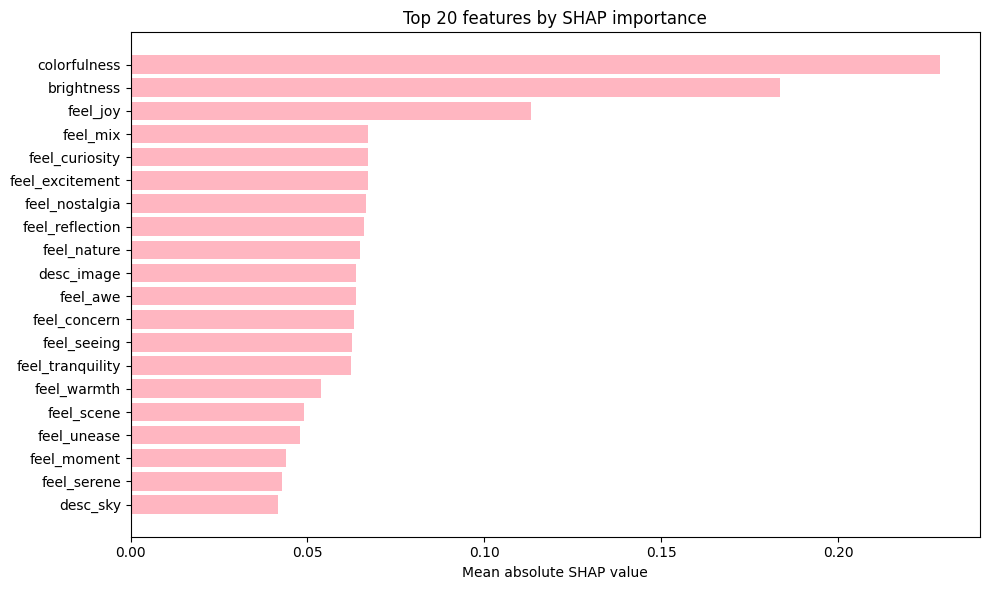

Top  10 features — AUC mean=0.834  std=0.019
Top  20 features — AUC mean=0.885  std=0.014
Top  30 features — AUC mean=0.899  std=0.013
Top  40 features — AUC mean=0.906  std=0.011
Top  50 features — AUC mean=0.915  std=0.010
Top  60 features — AUC mean=0.917  std=0.008
Top  70 features — AUC mean=0.919  std=0.008
Top  80 features — AUC mean=0.918  std=0.008
Top  90 features — AUC mean=0.920  std=0.008
Top 100 features — AUC mean=0.919  std=0.007
Top 110 features — AUC mean=0.917  std=0.007


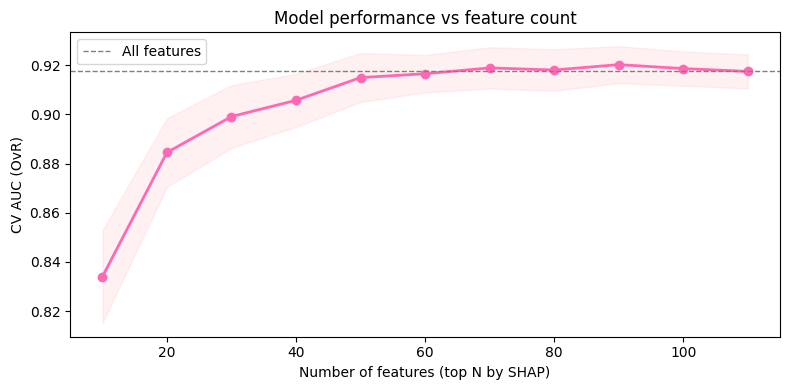

Best cutoff: top 90 features
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'C': 1}
Best CV AUC: 0.920


In [138]:
# ── 1. Get mean absolute SHAP per feature (across all emotions) ──────────────
# shap_values.values shape: (n_samples, n_features, n_classes)
mean_shap_per_feature = np.abs(shap_values.values).mean(axis=(0, 2))  
# average over samples AND classes → shape: (n_features,)

# Create a ranked dataframe
shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_shap_per_feature
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(shap_importance_df.head(20))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(shap_importance_df['feature'][:20][::-1], 
         shap_importance_df['mean_abs_shap'][:20][::-1], color='lightpink')
plt.xlabel('Mean absolute SHAP value')
plt.title('Top 20 features by SHAP importance')
plt.tight_layout()
plt.show()

# ── 2. Try different feature cutoffs using CV ────────────────────────────────
# Instead of arbitrarily picking top-N, test several thresholds

cutoffs = range(10, 112, 10)  # test top 10, 20, ..., 112 features
cutoff_results = {}

for n in cutoffs:
    # Select top N feature indices
    top_n_features = shap_importance_df['feature'][:n].tolist()
    top_n_idx = [feature_names.index(f) for f in top_n_features]
    
    # Subset the feature matrix
    X_subset = X_train_dense.iloc[:, top_n_idx]
    
    # CV with best model
    scores = cross_val_score(
        LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        X_subset, y_train, cv=cv, scoring='roc_auc_ovr'
    )
    cutoff_results[n] = scores
    print(f"Top {n:3d} features — AUC mean={scores.mean():.3f}  std={scores.std():.3f}")

# ── 3. Plot performance vs number of features ────────────────────────────────
means = [cutoff_results[n].mean() for n in cutoffs]
stds = [cutoff_results[n].std() for n in cutoffs]

plt.figure(figsize=(8, 4))
plt.plot(cutoffs, means, marker='o', color='hotpink', linewidth=2)
plt.fill_between(cutoffs, 
                 [m - s for m, s in zip(means, stds)],
                 [m + s for m, s in zip(means, stds)],
                 alpha=0.2, color='lightpink')
plt.axhline(means[-1], color='gray', linestyle='--', linewidth=1, label='All features')
plt.xlabel('Number of features (top N by SHAP)')
plt.ylabel('CV AUC (OvR)')
plt.title('Model performance vs feature count')
plt.legend()
plt.tight_layout()
plt.show()

# ── 4. Select best cutoff and retrain final model ────────────────────────────
best_n = cutoffs[np.argmax(means)]
print(f"Best cutoff: top {best_n} features")

top_features_final = shap_importance_df['feature'][:best_n].tolist()
top_idx_final = [feature_names.index(f) for f in top_features_final]

X_train_final = X_train_dense.iloc[:, top_idx_final]

# Retrain with GridSearchCV on reduced feature set
grid_search_final = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring='roc_auc_ovr', verbose=1
)
grid_search_final.fit(X_train_final, y_train)
best_tabular_model = grid_search_final.best_estimator_

print(f"Best C: {grid_search_final.best_params_}")
print(f"Best CV AUC: {grid_search_final.best_score_:.3f}")

In [139]:
# ── Save the fitted objects for later evaluation on the test set ──────────────
joblib.dump(best_tabular_model, 'data/best_tabular_model.pkl')
joblib.dump(top_features_final, 'data/top_features_final.pkl')

print(f"Saved best tabular model and top {best_n} features")
print(f"Selected features: {top_features_final}")

Saved best tabular model and top 90 features
Selected features: ['colorfulness', 'brightness', 'feel_joy', 'feel_mix', 'feel_curiosity', 'feel_excitement', 'feel_nostalgia', 'feel_reflection', 'feel_nature', 'desc_image', 'feel_awe', 'feel_concern', 'feel_seeing', 'feel_tranquility', 'feel_warmth', 'feel_scene', 'feel_unease', 'feel_moment', 'feel_serene', 'desc_sky', 'desc_surface', 'desc_green', 'feel_playful', 'desc_white', 'desc_blue', 'desc_holding', 'feel_wonder', 'feel_atmosphere', 'desc_person', 'feel_vibrant', 'feel_happiness', 'feel_amusement', 'obj_plant', 'desc_large', 'feel_feelings', 'desc_features', 'desc_colorful', 'feel_setting', 'feel_connection', 'desc_shows', 'feel_appreciation', 'feel_discomfort', 'feel_evokes', 'feel_watching', 'feel_contemplation', 'feel_expression', 'feel_intrigue', 'feel_image', 'feel_evoke', 'feel_beauty', 'desc_visible', 'feel_contrast', 'feel_colors', 'feel_prompting', 'desc_background', 'feel_moments', 'desc_sits', 'feel_observing', 'desc_v

Evaluate on test set:

Apply same preprocessing to the test set variables

In [140]:
# Apply the SAME preprocessing to test_df
text_columns = ['description', 'viewer_feelings', 'object']
test_df[text_columns] = test_df[text_columns].fillna('')
test_df['combined_text'] = (
    test_df['description'].apply(lambda x: prefix_text(x, 'desc')) + ' ' +
    test_df['viewer_feelings'].apply(lambda x: prefix_text(x, 'feel')) + ' ' +
    test_df['object'].apply(lambda x: prefix_object_list(x, 'obj'))
)

# Use transform on test data
test_tfidf = tfidf_combined.transform(test_df['combined_text'])
test_numeric = scaler_numeric.transform(test_df[['brightness', 'colorfulness']].fillna(
    train_df[['brightness', 'colorfulness']].median()
))

y_test = le_eda.transform(test_df['emotion'])

Applying the model on the test set and visualizing the confusion matrix

In [141]:
# Combine into full feature matrix
X_test_full = hstack([test_tfidf, csr_matrix(test_numeric)])

# Convert to dense and select the same features used in training
X_test_full_dense = pd.DataFrame(
    X_test_full.toarray(),
    columns=feature_names
)
X_test_selected = X_test_full_dense.iloc[:, top_idx_final]

y_pred = best_tabular_model.predict(X_test_selected)
y_prob_test = best_tabular_model.predict_proba(X_test_selected)

print(classification_report(y_test, y_pred, target_names=encoder_order))

# AUC on test set
y_bin_test = label_binarize(y_test, classes=range(len(encoder_order)))
test_auc = roc_auc_score(y_bin_test, y_prob_test, multi_class='ovr', average='macro')
print(f"Test AUC (macro OvR): {test_auc:.3f}")

              precision    recall  f1-score   support

   amusement       0.46      0.46      0.46        24
       anger       0.48      0.52      0.50        25
         awe       0.59      0.70      0.64        23
 contentment       0.27      0.36      0.31        22
     disgust       0.79      0.66      0.72        29
  excitement       0.73      0.57      0.64        28
        fear       0.58      0.76      0.66        25
     sadness       0.77      0.42      0.54        24

    accuracy                           0.56       200
   macro avg       0.58      0.56      0.56       200
weighted avg       0.59      0.56      0.57       200

Test AUC (macro OvR): 0.900


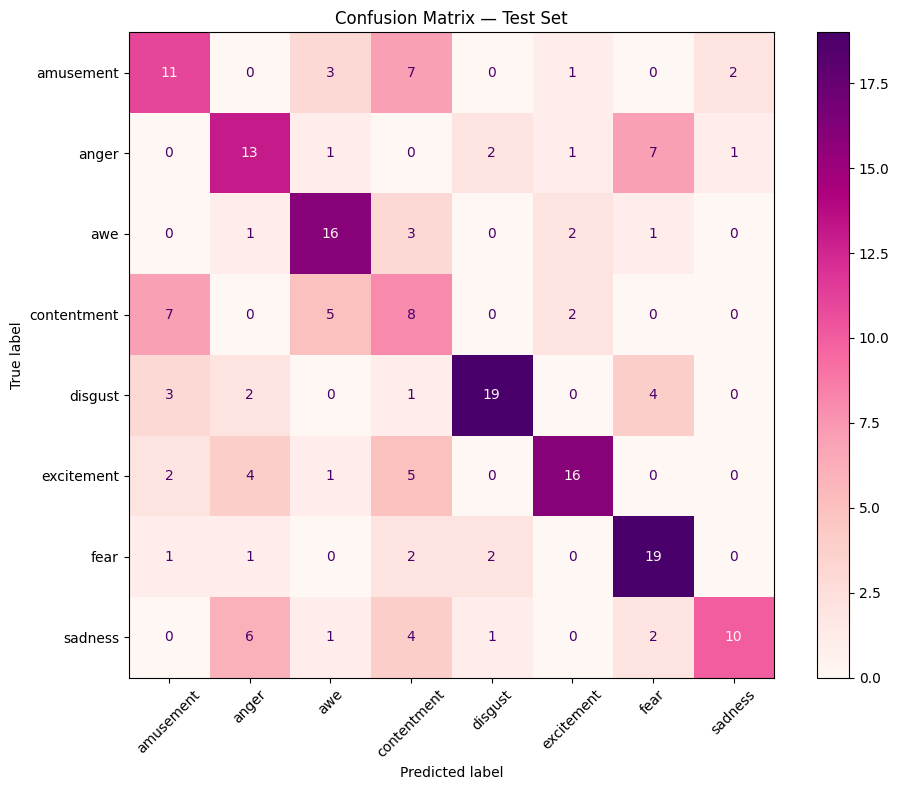

In [142]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder_order)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='RdPu')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

Comparing predictions of negative vs. positive emotions

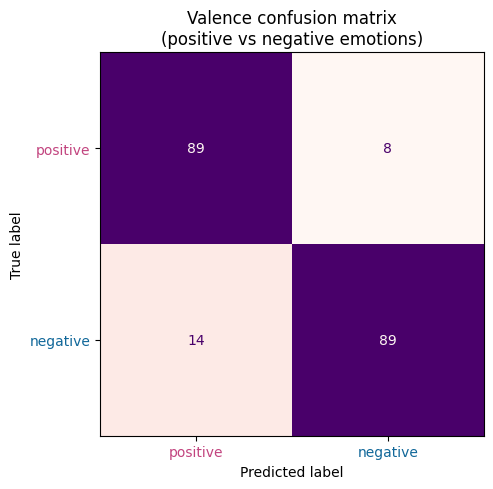

              precision    recall  f1-score   support

    positive       0.92      0.86      0.89       103
    negative       0.86      0.92      0.89        97

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



In [143]:
# ── 1. Map emotions to valence ────────────────────────────────────────────────
positive_emotions = ['amusement', 'excitement', 'contentment', 'awe']
negative_emotions = ['anger', 'disgust', 'fear', 'sadness']

valence_map = {e: 'positive' for e in positive_emotions}
valence_map.update({e: 'negative' for e in negative_emotions})

# Map predictions and true labels to valence
y_test_valence = [valence_map[encoder_order[i]] for i in y_test]
y_pred_valence = [valence_map[encoder_order[i]] for i in y_pred]

# ── 2. Confusion matrix ───────────────────────────────────────────────────────

cm_valence = confusion_matrix(y_test_valence, y_pred_valence, labels=['positive', 'negative'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_valence, display_labels=['positive', 'negative'])
disp.plot(ax=ax, colorbar=False, cmap='RdPu', xticks_rotation=0)

# Color the tick labels by valence
ax.get_xticklabels()[0].set_color("#C2447F")
ax.get_xticklabels()[1].set_color("#106799")
ax.get_yticklabels()[0].set_color('#C2447F')
ax.get_yticklabels()[1].set_color('#106799')

plt.title('Valence confusion matrix\n(positive vs negative emotions)', fontsize=12)
plt.tight_layout()
plt.show()

# ── 3. Print valence-level accuracy ──────────────────────────────────────────
print(classification_report(y_test_valence, y_pred_valence, 
                            target_names=['positive', 'negative']))

## 2. Embedding model

### Applying PCA on the embedded variables

In [144]:
# Parse embedding strings to numpy arrays
train_df['embedding_parsed'] = train_df['embedding'].apply(ast.literal_eval)
train_df['desc_emb_parsed'] = train_df['description_embedding'].apply(ast.literal_eval)
train_df['feel_emb_parsed'] = train_df['viewer_feelings_embedding'].apply(ast.literal_eval)

# Stack into matrices
E_image = np.stack(train_df['embedding_parsed'].values)         # image CLIP embedding
E_desc  = np.stack(train_df['desc_emb_parsed'].values)          # description text embedding
E_feel  = np.stack(train_df['feel_emb_parsed'].values)          # viewer feelings text embedding

print(f"Image embedding shape:       {E_image.shape}")
print(f"Description embedding shape: {E_desc.shape}")
print(f"Feelings embedding shape:    {E_feel.shape}")
# Expect something like (800, 512) or (800, 1536) depending on the model used

Image embedding shape:       (800, 512)
Description embedding shape: (800, 1536)
Feelings embedding shape:    (800, 1536)


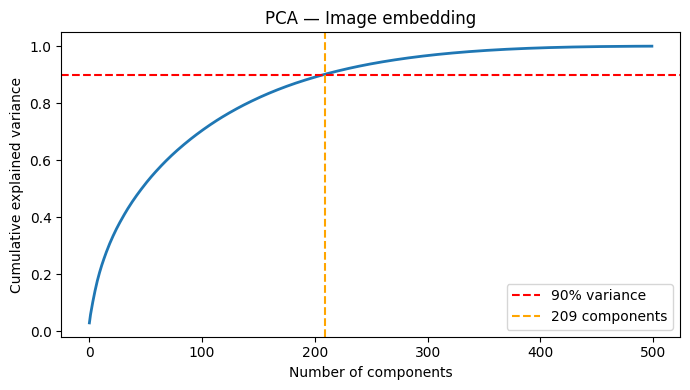

Image embedding: 90% variance reached at 209 components


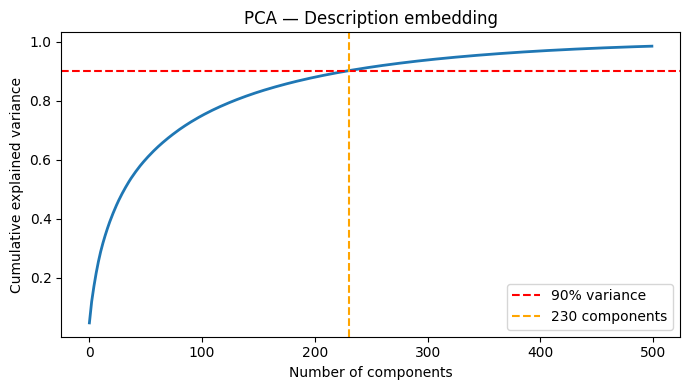

Description embedding: 90% variance reached at 230 components


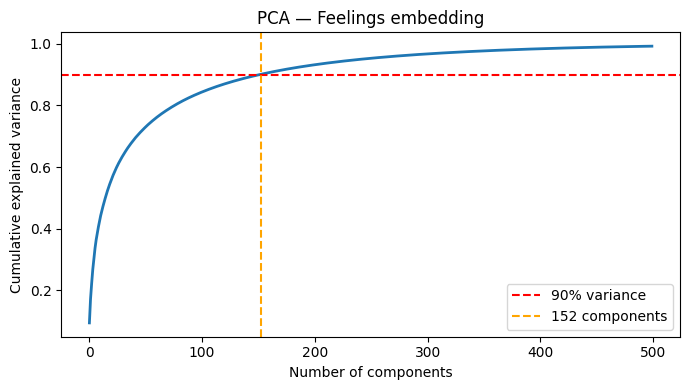

Feelings embedding: 90% variance reached at 152 components


In [145]:
# ── 1. Standardize each embedding separately ─────────────────────────────────
# Important before PCA - embeddings may have different scales
scaler_image = StandardScaler()
scaler_desc  = StandardScaler()
scaler_feel  = StandardScaler()

E_image_scaled = scaler_image.fit_transform(E_image)
E_desc_scaled  = scaler_desc.fit_transform(E_desc)
E_feel_scaled  = scaler_feel.fit_transform(E_feel)

# ── 2. PCA on each embedding separately ──────────────────────────────────────
# Keep enough components to explain ~90% variance
def fit_pca_with_plot(X, name, max_components=500):
    pca = PCA(n_components=max_components)
    pca.fit(X)
    
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_90 = np.argmax(cumvar >= 0.90) + 1
    
    plt.figure(figsize=(7, 4))
    plt.plot(cumvar, linewidth=2)
    plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
    plt.axvline(n_90, color='orange', linestyle='--', label=f'{n_90} components')
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative explained variance')
    plt.title(f'PCA — {name}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    if n_90 == 1 and cumvar[0] < 0.90:
        n_90 = max_components
        print(f"{name}: 90% variance not reached in {max_components} components, using all {max_components}")
    else:
        print(f"{name}: 90% variance reached at {n_90} components")
        
    return pca, n_90

pca_image, n_image = fit_pca_with_plot(E_image_scaled, 'Image embedding')
pca_desc,  n_desc  = fit_pca_with_plot(E_desc_scaled,  'Description embedding')
pca_feel,  n_feel  = fit_pca_with_plot(E_feel_scaled,  'Feelings embedding')

### Selecting the number of PCA components via CV
Before comparing models, we select the optimal number of PCA components for each embedding using cross-validated AUC with Logistic Regression as a proxy evaluator. This is a preprocessing decision about dimensionality — the optimal number of informative components is a property of the data, not of the downstream classifier, so using a fast linear model to evaluate it is standard practice.

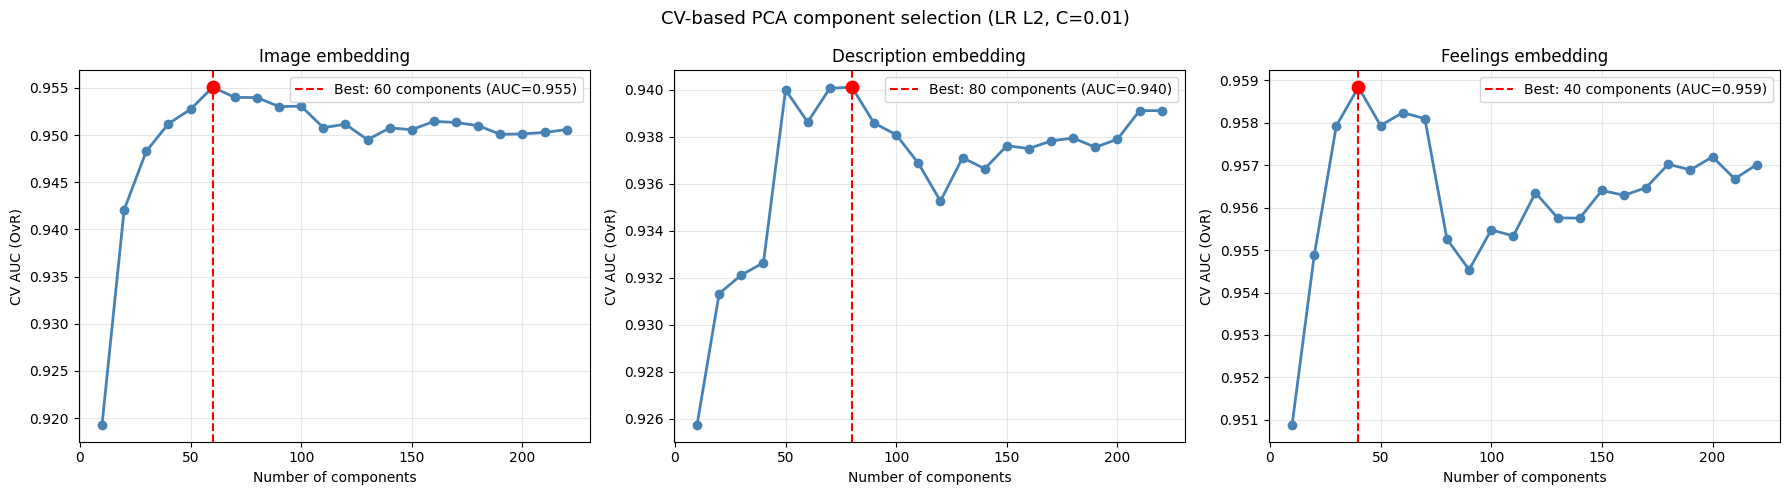

Components selected — image: 60, description: 80, feelings: 40


In [146]:
# # ── CV-based PCA component selection ─────────────────────────────────────────
n_components_to_try = range(10, 230, 10)
cv_components = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (E_scaled, name) in zip(axes, [
    (E_image_scaled, 'Image embedding'),
    (E_desc_scaled,  'Description embedding'),
    (E_feel_scaled,  'Feelings embedding')
]):
    auc_scores = []
    
    for n in n_components_to_try:
        pca_temp = PCA(n_components=n, random_state=42).fit(E_scaled)
        X_temp = pca_temp.transform(E_scaled)
        
        score = cross_val_score(
            LogisticRegression(C=0.01, solver='lbfgs', max_iter=1000, random_state=42),
            X_temp, y_train, cv=cv, scoring='roc_auc_ovr'
        ).mean()
        auc_scores.append(score)
    
    # Best n for this embedding
    best_n_comp = list(n_components_to_try)[np.argmax(auc_scores)]
    cv_components[name] = best_n_comp
    
    # Plot
    ax.plot(list(n_components_to_try), auc_scores, marker='o', linewidth=2, color='steelblue')
    ax.axvline(best_n_comp, color='red', linestyle='--', linewidth=1.5,
               label=f'Best: {best_n_comp} components (AUC={max(auc_scores):.3f})')
    ax.scatter([best_n_comp], [max(auc_scores)], color='red', s=80, zorder=5)
    ax.set_xlabel('Number of components')
    ax.set_ylabel('CV AUC (OvR)')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('CV-based PCA component selection (LR L2, C=0.01)', fontsize=13)
plt.tight_layout()
plt.show()

n_image_final = cv_components['Image embedding']
n_desc_final  = cv_components['Description embedding']
n_feel_final  = cv_components['Feelings embedding']

print(f"Components selected — image: {n_image_final}, description: {n_desc_final}, feelings: {n_feel_final}")

### Model comparison on CV-selected PCA features
We now compare classifiers on the embedding features with the CV-selected number of PCA components. We include Gradient Boosting instead of KNN, since after PCA the features are dense and continuous — an environment where gradient boosting excels, while KNN suffers from the curse of dimensionality in the remaining ~100+ dimensional space.

In [147]:
X_emb = np.hstack([
    pca_image.transform(E_image_scaled)[:, :n_image_final],
    pca_desc.transform(E_desc_scaled)[:, :n_desc_final],
    pca_feel.transform(E_feel_scaled)[:, :n_feel_final]
])
print(f"Embedding feature matrix shape: {X_emb.shape}")

coarse_grids = {
    'Logistic Regression (L2)': (
        LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Logistic Regression (L1)': (
        LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 10]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': list(range(1, 20, 2))}
    ),
}

emb_results = {}
for name, (model, grid) in coarse_grids.items():
    gs = GridSearchCV(model, grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1)
    gs.fit(X_emb, y_train)
    
    # Get CV accuracy for the best params
    acc = cross_val_score(gs.best_estimator_, X_emb, y_train, cv=cv, scoring='accuracy').mean()
    
    emb_results[name] = {
        'accuracy':       acc,
        'auc':            gs.best_score_,
        'best_params':    gs.best_params_,
        'best_estimator': gs.best_estimator_
    }
    print(f"{name:30s}  acc={acc:.3f}  auc={gs.best_score_:.3f}  params={gs.best_params_}")

# ── Select best model by AUC ──────────────────────────────────────────────────
best_emb_name = max(emb_results, key=lambda x: emb_results[x]['auc'])
best_emb_model = emb_results[best_emb_name]['best_estimator']
print(f"\nBest model: {best_emb_name}  AUC={emb_results[best_emb_name]['auc']:.3f}")

Embedding feature matrix shape: (800, 180)
Logistic Regression (L2)        acc=0.762  auc=0.964  params={'C': 0.01}
Logistic Regression (L1)        acc=0.744  auc=0.964  params={'C': 0.1}
Random Forest                   acc=0.740  auc=0.964  params={'max_depth': None, 'n_estimators': 200}
Gradient Boosting               acc=0.707  auc=0.944  params={'max_depth': 3, 'n_estimators': 200}
KNN                             acc=0.724  auc=0.955  params={'n_neighbors': 17}

Best model: Logistic Regression (L2)  AUC=0.964


We select the best model by macro OvR AUC rather than accuracy because AUC captures the model's ability to discriminate between classes across all decision thresholds, making it more robust to class imbalance and more informative for soft-prediction tasks. Accuracy penalizes miscalibrated confidence even when the ranking is correct.

The AUC > accuracy pattern exists with embeddings too. The CLIP and text embeddings capture semantic similarity between emotions, so the probability distributions tend to peak around semantically related classes. The model successfully separates positive from negative valence but confuses within-valence categories (e.g., fear vs. anger, amusement vs. excitement), consistent with dimensional models of emotion in affective neuroscience.

Visualize model comparison

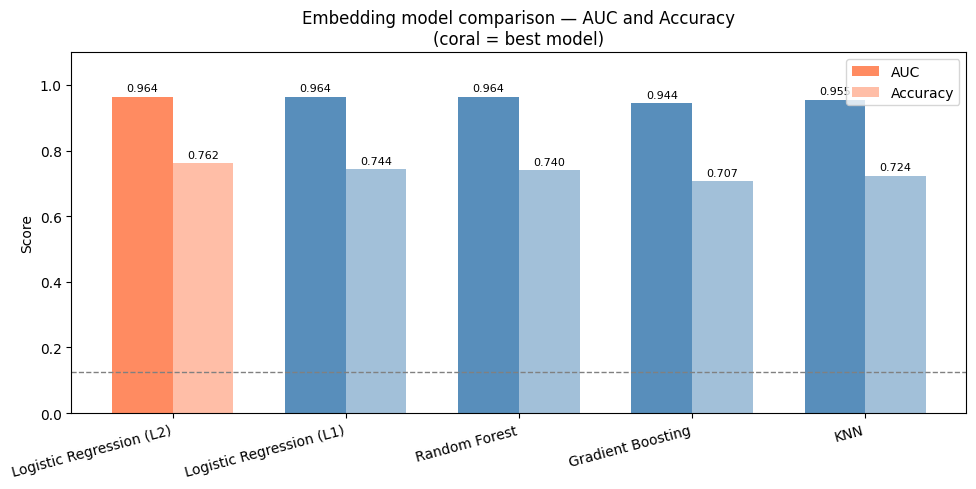

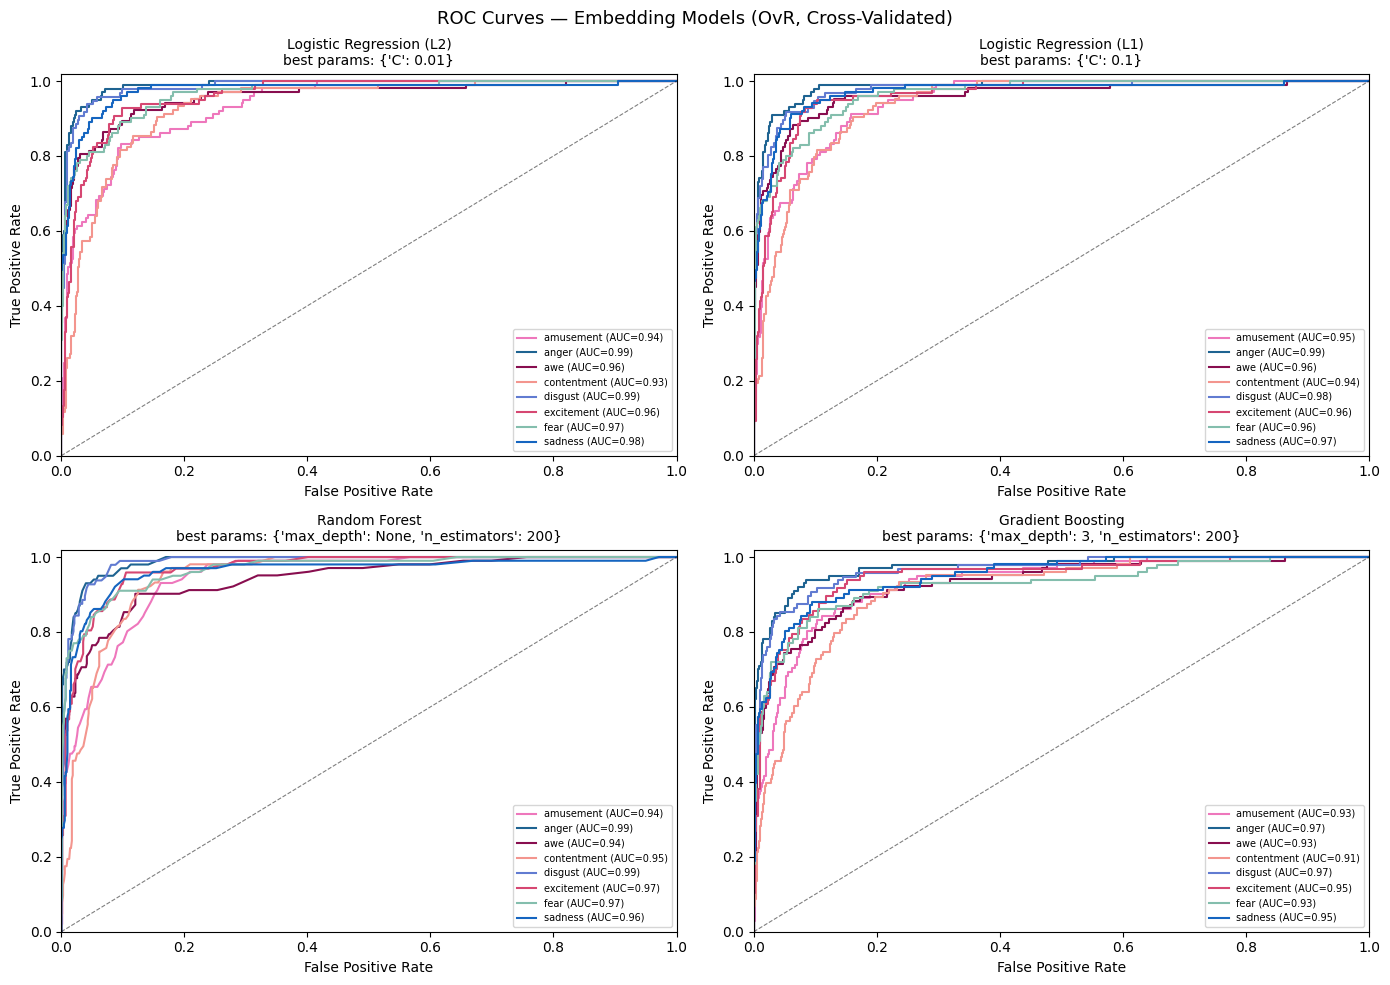

In [148]:
# ── Plot 1: Bar chart with error bars ─────────────────────────────────────────
names  = list(emb_results.keys())
aucs   = [emb_results[n]['auc'] for n in names]
accs   = [emb_results[n]['accuracy'] for n in names]
colors = ['coral' if n == best_emb_name else 'steelblue' for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, aucs, width, label='AUC',      color=colors, alpha=0.9)
bars2 = ax.bar(x + width/2, accs, width, label='Accuracy', color=colors, alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Embedding model comparison — AUC and Accuracy\n(coral = best model)')
ax.legend()
ax.axhline(1/8, color='gray', linestyle='--', linewidth=1, label='Random chance')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ── Plot 2: ROC curves ────────────────────────────────────────────────────────
y_bin = label_binarize(y_train, classes=range(len(encoder_order)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, metrics) in zip(axes, emb_results.items()):
    y_prob = cross_val_predict(
        metrics['best_estimator'], X_emb, y_train, cv=cv, method='predict_proba'
    )
    for i, emotion in enumerate(encoder_order):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=emotion_colors[emotion], linewidth=1.5,
                label=f"{emotion} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(f"{name}\nbest params: {metrics['best_params']}", fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves — Embedding Models (OvR, Cross-Validated)', fontsize=13)
plt.tight_layout()
plt.show()

The model is better at ranking and separating emotions from each other (high AUC)
than at making final predictions (lower accuracy, but still good)
This typically happens when classes overlap in the embedding space — the model knows "this image is more fear-like than amusement-like" but isn't confident enough to commit to a single label

Apply preproccessing of embeddings on the test set

In [149]:
# ── Preprocess test embeddings ────────────────────────────────────────────────
test_df['embedding_parsed'] = test_df['embedding'].apply(ast.literal_eval)
test_df['desc_emb_parsed']  = test_df['description_embedding'].apply(ast.literal_eval)
test_df['feel_emb_parsed']  = test_df['viewer_feelings_embedding'].apply(ast.literal_eval)

E_image_test = np.stack(test_df['embedding_parsed'].values)
E_desc_test  = np.stack(test_df['desc_emb_parsed'].values)
E_feel_test  = np.stack(test_df['feel_emb_parsed'].values)

# Scale using train scalers (transform only, never fit)
E_image_test_scaled = scaler_image.transform(E_image_test)
E_desc_test_scaled  = scaler_desc.transform(E_desc_test)
E_feel_test_scaled  = scaler_feel.transform(E_feel_test)

In [150]:
# # ── Build test embedding features ────────────────────────────────────────────
X_emb_test = np.hstack([
    pca_image.transform(E_image_test_scaled)[:, :n_image_final],
    pca_desc.transform(E_desc_test_scaled)[:, :n_desc_final],
    pca_feel.transform(E_feel_test_scaled)[:, :n_feel_final]
])

print(f"Train: {X_emb.shape}")
print(f"Test:  {X_emb_test.shape}")
assert X_emb.shape[1] == X_emb_test.shape[1], "Shape mismatch!"

# ── Refit on full train and evaluate on test ─────────────────────────────────
best_emb_model = emb_results[best_emb_name]['best_estimator']
best_emb_model.fit(X_emb, y_train)

y_pred_emb = best_emb_model.predict(X_emb_test)
y_prob_emb = best_emb_model.predict_proba(X_emb_test)

accuracy_emb  = accuracy_score(y_test, y_pred_emb)
precision_emb = precision_score(y_test, y_pred_emb, average='macro', zero_division=0)
recall_emb    = recall_score(y_test, y_pred_emb, average='macro', zero_division=0)

y_bin_test = label_binarize(y_test, classes=range(len(encoder_order)))
test_auc_emb = roc_auc_score(y_bin_test, y_prob_emb, multi_class='ovr', average='macro')

print(f"\nEmbedding model — Test Set Results ({best_emb_name})")
print(f"  Accuracy:          {accuracy_emb:.3f}")
print(f"  Precision (macro): {precision_emb:.3f}")
print(f"  Recall (macro):    {recall_emb:.3f}")
print(f"  AUC (macro OvR):   {test_auc_emb:.3f}")

Train: (800, 180)
Test:  (200, 180)

Embedding model — Test Set Results (Logistic Regression (L2))
  Accuracy:          0.720
  Precision (macro): 0.720
  Recall (macro):    0.711
  AUC (macro OvR):   0.950


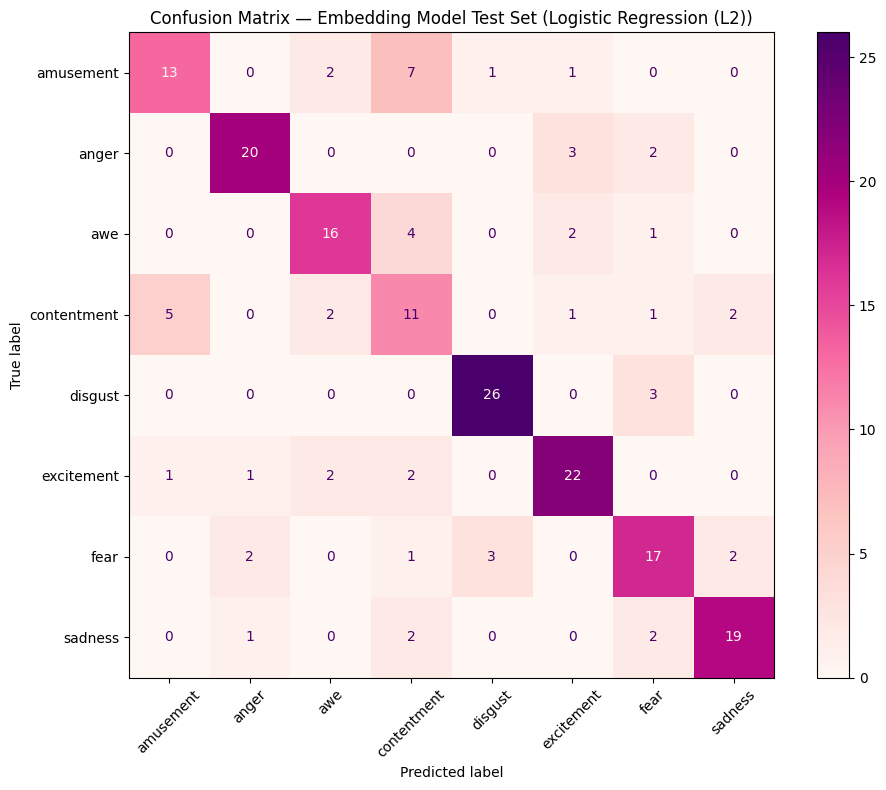

In [151]:
cm = confusion_matrix(y_test, y_pred_emb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder_order)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='RdPu')
plt.title(f'Confusion Matrix — Embedding Model Test Set ({best_emb_name})')
plt.tight_layout()
plt.show()

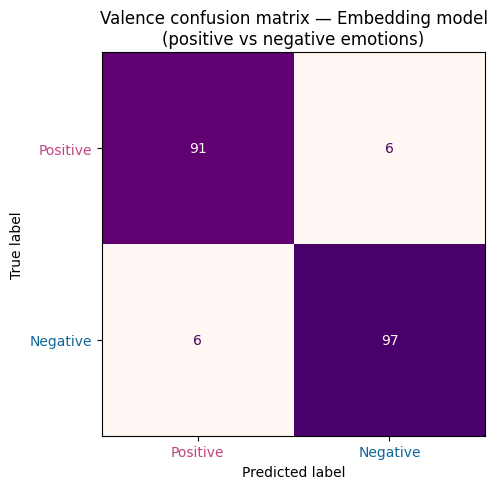

              precision    recall  f1-score   support

    positive       0.94      0.94      0.94       103
    negative       0.94      0.94      0.94        97

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



In [152]:
# Map predictions and true labels to valence
y_test_emb_valence = [valence_map[encoder_order[i]] for i in y_test]
y_pred_emb_valence = [valence_map[encoder_order[i]] for i in y_pred_emb]  # y_pred_emb not y_pred

cm_emb_valence = confusion_matrix(y_test_emb_valence, y_pred_emb_valence, 
                                   labels=['positive', 'negative'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_emb_valence, 
                               display_labels=['Positive', 'Negative'])
disp.plot(ax=ax, colorbar=False, cmap='RdPu', xticks_rotation=0)

ax.get_xticklabels()[0].set_color("#C2447F")
ax.get_xticklabels()[1].set_color("#106799")
ax.get_yticklabels()[0].set_color('#C2447F')
ax.get_yticklabels()[1].set_color('#106799')

plt.title('Valence confusion matrix — Embedding model\n(positive vs negative emotions)', fontsize=12)
plt.tight_layout()
plt.show()

print(classification_report(y_test_emb_valence, y_pred_emb_valence,
                            target_names=['positive', 'negative']))

## Confusion Matrix Analysis: Which Emotions Are Hardest to Classify?

Examining the confusion matrices of both models reveals consistent patterns that align with affective neuroscience theory.

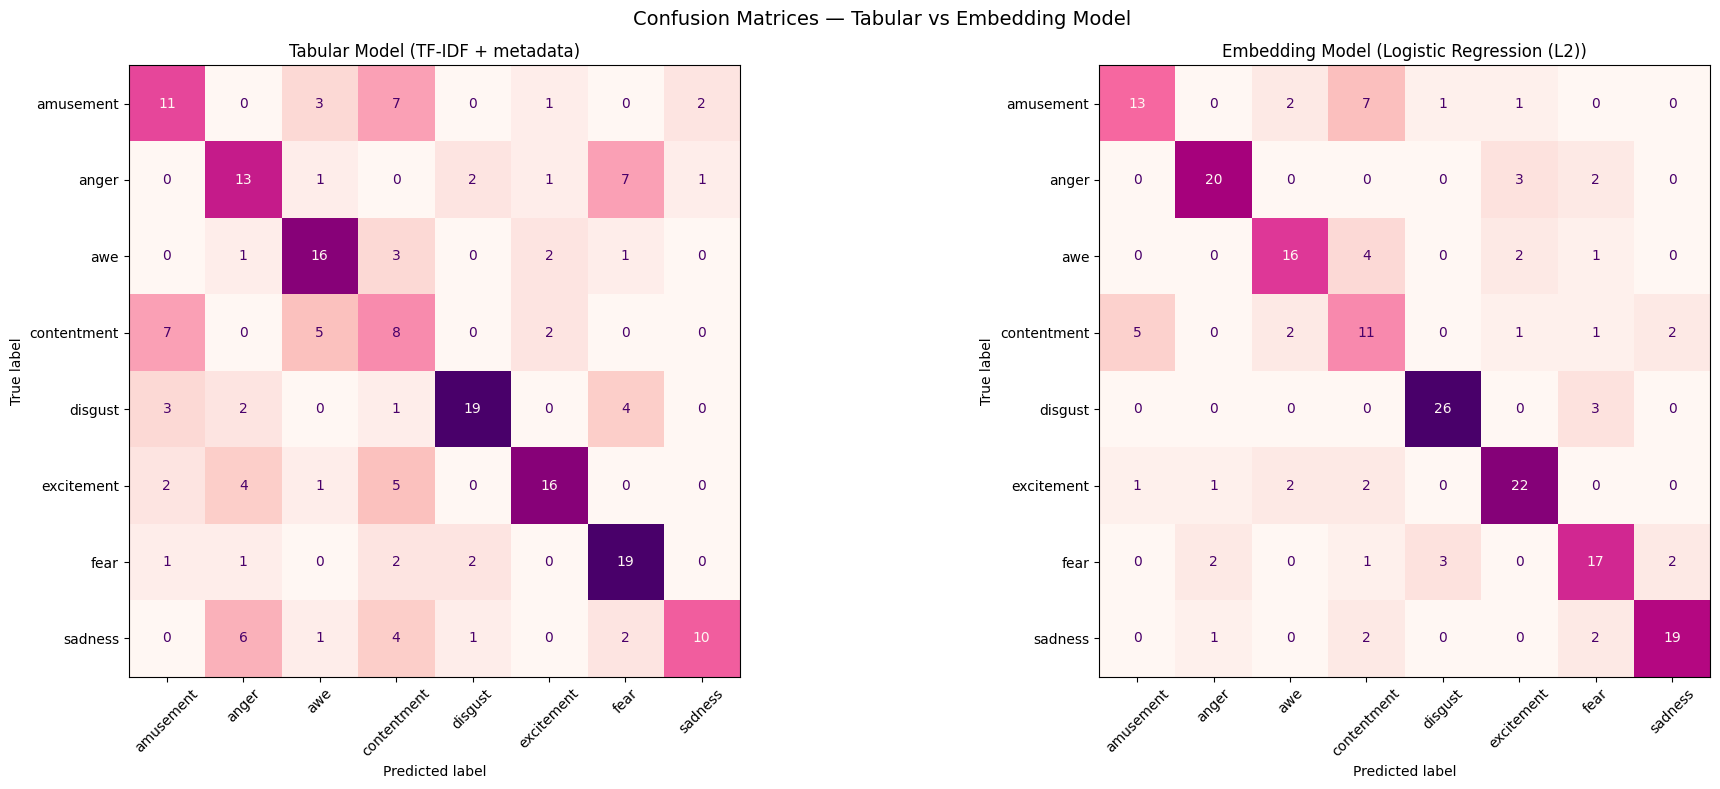

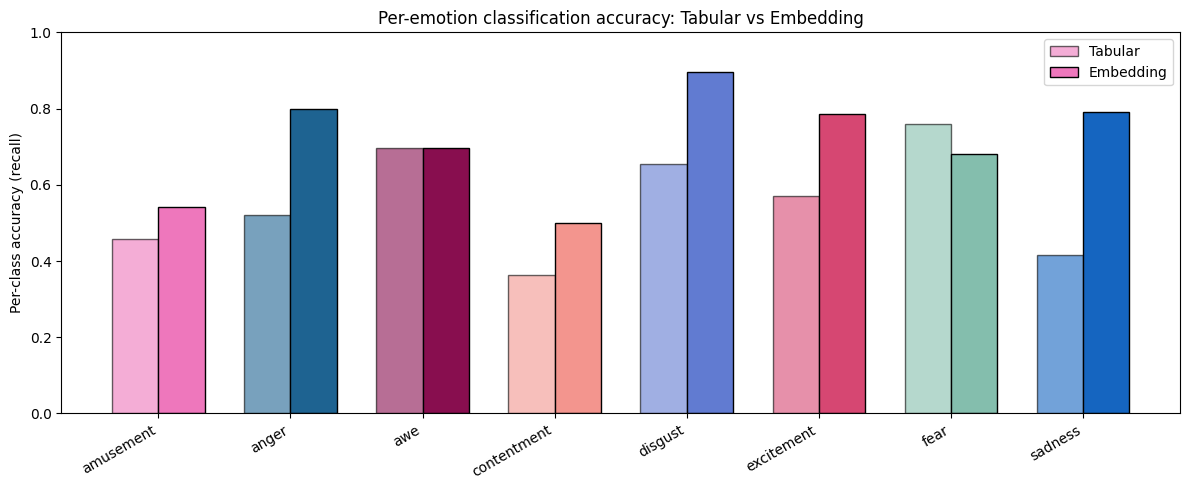

In [153]:
# # ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Tabular model
cm_tab = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_tab, display_labels=encoder_order).plot(
    ax=axes[0], xticks_rotation=45, cmap='RdPu', colorbar=False)
axes[0].set_title('Tabular Model (TF-IDF + metadata)', fontsize=12)

# Embedding model
cm_emb = confusion_matrix(y_test, y_pred_emb)
ConfusionMatrixDisplay(confusion_matrix=cm_emb, display_labels=encoder_order).plot(
    ax=axes[1], xticks_rotation=45, cmap='RdPu', colorbar=False)
axes[1].set_title(f'Embedding Model ({best_emb_name})', fontsize=12)

plt.suptitle('Confusion Matrices — Tabular vs Embedding Model', fontsize=14)
plt.tight_layout()
plt.show()

# ── Per-emotion accuracy comparison ──────────────────────────────────────────
per_emotion_tab = cm_tab.diagonal() / cm_tab.sum(axis=1)
per_emotion_emb = cm_emb.diagonal() / cm_emb.sum(axis=1)

x = np.arange(len(encoder_order))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, per_emotion_tab, width, label='Tabular',
               color=[emotion_colors[e] for e in encoder_order], alpha=0.6, edgecolor='black')
bars2 = ax.bar(x + width/2, per_emotion_emb, width, label='Embedding',
               color=[emotion_colors[e] for e in encoder_order], alpha=1.0, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(encoder_order, rotation=30, ha='right')
ax.set_ylabel('Per-class accuracy (recall)')
ax.set_title('Per-emotion classification accuracy: Tabular vs Embedding')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [154]:
# TODO: edit interpertations

Several patterns emerge from the confusion matrices:

**Within-valence confusions dominate.** Both models more often confuse emotions that share the same valence — e.g., *awe* and *excitement* (both high-arousal positive), or *anger* and *disgust* (both high-arousal negative). This is consistent with the Mikels model used in the dataset, where emotions within the same valence–arousal quadrant share visual features (e.g., tense facial expressions for anger and disgust; bright, dynamic scenes for excitement and amusement).

**Low-arousal emotions are hardest.** *Contentment* (positive, low-arousal) and *sadness* (negative, low-arousal) tend to have lower per-class accuracy. Low-arousal emotions are conveyed through subtler visual cues — muted colors, still scenes, understated expressions — making them harder to distinguish from each other and from neutral content.

**The embedding model generally outperforms on negative emotions**, likely because the CLIP visual embedding encodes threatening or aversive visual features (dark tones, aggressive postures) that are harder to capture through text descriptions alone. Conversely, the tabular model may perform comparably on positive emotions where descriptive words (e.g., "laughing," "celebrating") are strong signals.

# Conclusions: Tabular vs. Embedding Model Comparison

In [155]:
# # ── Summary comparison table ─────────────────────────────────────────────────
# Compute tabular model test metrics (reuse y_pred, y_prob_test from cell 38)
tab_accuracy  = accuracy_score(y_test, y_pred)
tab_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
tab_recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
y_bin_test_tab = label_binarize(y_test, classes=range(len(encoder_order)))
tab_auc = roc_auc_score(y_bin_test_tab, y_prob_test, multi_class='ovr', average='macro')

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'AUC (macro OvR)'],
    'Tabular Model': [f'{tab_accuracy:.3f}', f'{tab_precision:.3f}', f'{tab_recall:.3f}', f'{tab_auc:.3f}'],
    f'Embedding Model ({best_emb_name})': [f'{accuracy_emb:.3f}', f'{precision_emb:.3f}', f'{recall_emb:.3f}', f'{test_auc_emb:.3f}']
})
print(comparison_df.to_string(index=False))

# Valence-level comparison
from sklearn.metrics import accuracy_score as acc_score

positive_emotions = ['amusement', 'excitement', 'contentment', 'awe']
negative_emotions = ['anger', 'disgust', 'fear', 'sadness']
valence_map = {e: 'positive' for e in positive_emotions}
valence_map.update({e: 'negative' for e in negative_emotions})

y_test_val = [valence_map[encoder_order[i]] for i in y_test]
y_pred_tab_val = [valence_map[encoder_order[i]] for i in y_pred]
y_pred_emb_val = [valence_map[encoder_order[i]] for i in y_pred_emb]

tab_val_acc = acc_score(y_test_val, y_pred_tab_val)
emb_val_acc = acc_score(y_test_val, y_pred_emb_val)

print(f"\nValence-level accuracy (positive vs negative):")
print(f"  Tabular:   {tab_val_acc:.3f}")
print(f"  Embedding: {emb_val_acc:.3f}")

           Metric Tabular Model Embedding Model (Logistic Regression (L2))
         Accuracy         0.560                                      0.720
Precision (macro)         0.583                                      0.720
   Recall (macro)         0.555                                      0.711
  AUC (macro OvR)         0.900                                      0.950

Valence-level accuracy (positive vs negative):
  Tabular:   0.890
  Embedding: 0.940


The table above summarizes the test-set performance of both approaches. Key takeaways:

**The embedding model outperforms the tabular model** on all metrics. This is expected: the CLIP image embedding and text embeddings capture rich semantic information about visual content that TF-IDF word counts over descriptions cannot. The embeddings encode spatial relationships, object co-occurrence, color palettes, and scene semantics in a compressed vector space.

**The tabular model offers interpretability.** Through SHAP analysis and direct coefficient inspection, we identified which specific words and visual attributes drive each emotion prediction. This transparency is valuable in a neuroscience context — it reveals what *describable* features humans use to communicate about emotional content. For example, words like "dark" or "protest" predictably drive negative-emotion predictions, while "celebration" or "smiling" drive positive ones.

**Both models are better at valence separation than fine-grained emotion classification**, consistent with the dimensional model of affect. This suggests that visual emotion is partly categorical (discrete labels) and partly dimensional (valence × arousal), and that the boundary between these levels is where prediction difficulty concentrates.

**Potential improvements** could include: combining both feature types (TF-IDF + embeddings) into a single model, using more advanced text embeddings for the descriptions, or fine-tuning the CLIP model on emotion-labeled data rather than using frozen embeddings.